In [14]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 0 — IMPORTS
# ══════════════════════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings("ignore")

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from scipy.stats import randint, uniform, loguniform

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, average_precision_score, confusion_matrix, brier_score_loss,
    roc_curve, precision_recall_curve, classification_report
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

SEED = 42
TARGET_COL = "default"
CATEGORICAL_COLS = ["SEX", "EDUCATION", "MARRIAGE"]

# ── [FIX-1] FAST_MODE = False cho kết quả nộp khóa luận ──────────────────────
# FAST_MODE = True  chỉ dùng khi debug/kiểm tra pipeline, KHÔNG dùng khi nộp.
# Kết quả trong khóa luận phải đến từ FAST_MODE = False (5-fold, 20 iter).
FAST_MODE = False          # ← ĐÃ SỬA: False để đảm bảo độ tin cậy học thuật
N_SPLITS = 3 if FAST_MODE else 5
N_ITER_SEARCH = 8 if FAST_MODE else 20
SEARCH_N_JOBS = 1
RF_N_JOBS = -1
XGB_N_JOBS = 1
SEARCH_VERBOSE = 1
SMOTE_K_NEIGHBORS = 5

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

print(f"[FIX-1] FAST_MODE={FAST_MODE} | N_SPLITS={N_SPLITS} | N_ITER_SEARCH={N_ITER_SEARCH}")

[FIX-1] FAST_MODE=False | N_SPLITS=5 | N_ITER_SEARCH=20


In [15]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — ĐỌC DỮ LIỆU VÀ LÀM SẠCH
# ══════════════════════════════════════════════════════════════════════════════
# Notebook này tự tìm file dữ liệu ở các vị trí phổ biến để chạy được trên
# Google Colab, Jupyter local hoặc thư mục làm việc hiện tại.
# Nếu cần, chỉ sửa DATA_PATH bên dưới.
DATA_PATH = None  # ví dụ: "default of credit card clients.csv"

candidate_paths = []
if DATA_PATH is not None:
    candidate_paths.append(Path(DATA_PATH))

candidate_paths += [
    Path("/content/default of credit card clients.csv"),
    Path("/content/default_of_credit_card_clients.csv"),
    Path("/mnt/data/default of credit card clients.csv"),
    Path("/mnt/data/default_of_credit_card_clients.csv"),
    Path("default of credit card clients.csv"),
    Path("default_of_credit_card_clients.csv"),
]

# Tìm thêm các file csv có tên gần giống trong thư mục hiện tại và /content, /mnt/data
for folder in [Path.cwd(), Path("/content"), Path("/mnt/data")]:
    if folder.exists():
        for p in folder.glob("*.csv"):
            if "credit" in p.name.lower() or "default" in p.name.lower():
                candidate_paths.append(p)

file_path = next((p for p in candidate_paths if p.exists()), None)
if file_path is None:
    raise FileNotFoundError(
        "Không tìm thấy file dữ liệu CSV. Hãy đặt file 'default of credit card clients.csv' "
        "cùng thư mục với notebook hoặc sửa biến DATA_PATH trong cell này."
    )

print(f"Đang đọc dữ liệu từ: {file_path}")
df_raw = pd.read_csv(file_path)

if "default payment next month" not in df_raw.columns:
    candidate_cols = df_raw.iloc[0].astype(str).tolist()
    if "default payment next month" in candidate_cols:
        df = df_raw.copy()
        df.columns = candidate_cols
        df = df.drop(index=0).reset_index(drop=True)
    else:
        raise ValueError("Không tìm thấy cột mục tiêu 'default payment next month'.")
else:
    df = df_raw.copy()

df = df.rename(columns={"default payment next month": TARGET_COL})
if "ID" in df.columns:
    df = df.drop(columns=["ID"])

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Làm sạch mã bất thường theo thực hành thường dùng với UCI Taiwan dataset
if "EDUCATION" in df.columns:
    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
if "MARRIAGE" in df.columns:
    df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("Shape:", df.shape)
display(df.head())
print("\nMissing values:", df.isnull().sum().sum())

for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    if col in df.columns:
        print(f"\n{col}:")
        display(df[col].value_counts(dropna=False).sort_index().to_frame("count"))


Đang đọc dữ liệu từ: /content/default of credit card clients.csv
Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0



Missing values: 0

SEX:


,count
SEX,
1,11888
2,18112



EDUCATION:


,count
EDUCATION,
1,10585
2,14030
3,4917
4,468



MARRIAGE:


,count
MARRIAGE,
1,13659
2,15964
3,377


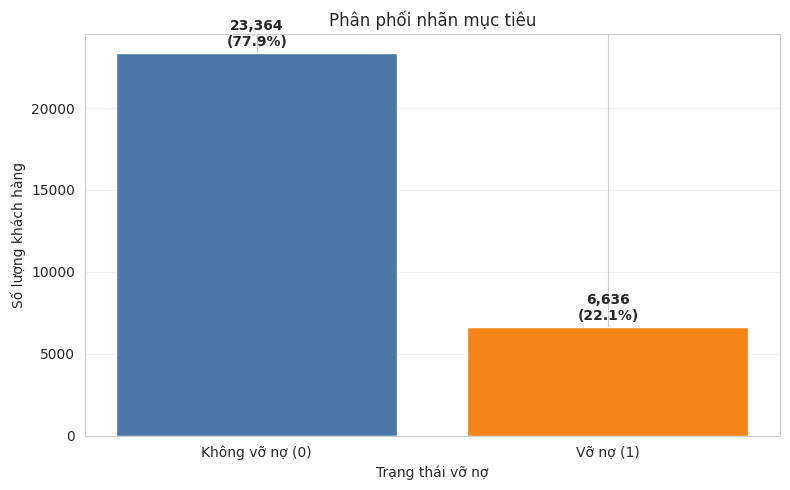

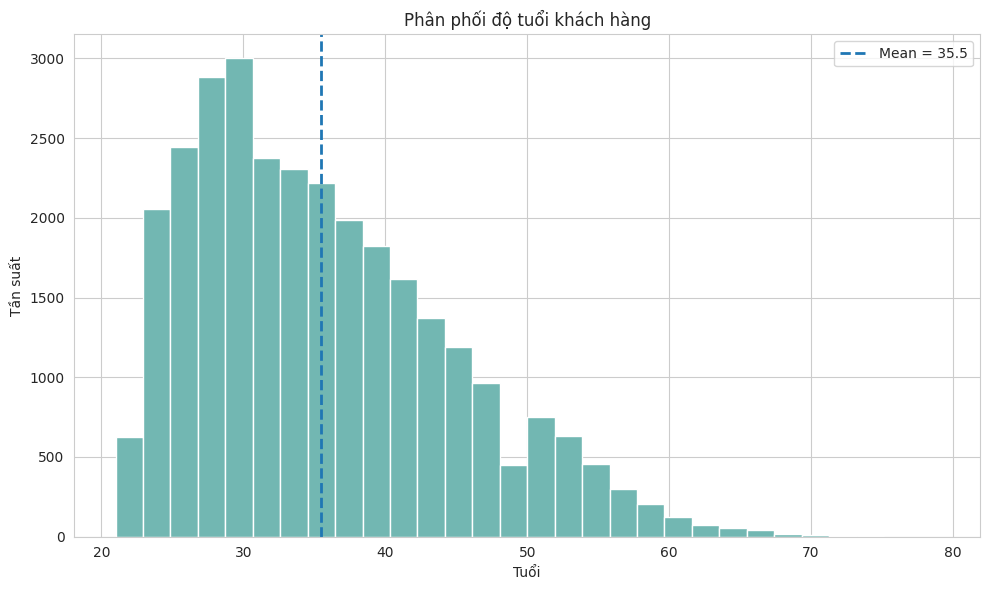

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — EDA NGẮN GỌN
# ══════════════════════════════════════════════════════════════════════════════
label_counts = df[TARGET_COL].value_counts().sort_index()
label_pct    = df[TARGET_COL].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8, 5))
bar_labels = ["Không vỡ nợ (0)", "Vỡ nợ (1)"]
bar_colors = ["#4C78A8", "#F58518"]
bars = plt.bar(bar_labels, label_counts.values, color=bar_colors, edgecolor="white")
plt.title("Phân phối nhãn mục tiêu")
plt.ylabel("Số lượng khách hàng")
plt.xlabel("Trạng thái vỡ nợ")
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 250, f"{v:,}\n({label_pct.iloc[i]:.1f}%)",
             ha="center", va="bottom", fontweight="bold")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.hist(df["AGE"].dropna(), bins=30, edgecolor="white", color="#72B7B2")
plt.axvline(df["AGE"].mean(), linestyle="--", linewidth=2,
            label=f"Mean = {df['AGE'].mean():.1f}")
plt.title("Phân phối độ tuổi khách hàng")
plt.xlabel("Tuổi")
plt.ylabel("Tần suất")
plt.legend()
plt.tight_layout()
plt.show()


## Feature Engineering — Công thức toán học

Năm đặc trưng phái sinh được xây dựng theo các công thức sau:

$$\text{avg\_bill\_amt} = \frac{1}{6}\sum_{i=1}^{6}\text{BILL\_AMT}_i$$

$$\text{util\_rate} = \frac{\text{avg\_bill\_amt}}{\text{LIMIT\_BAL}}$$

$$\text{avg\_pay\_amt} = \frac{1}{6}\sum_{i=1}^{6}\text{PAY\_AMT}_i$$

$$\text{pay\_ratio} = \frac{\text{avg\_pay\_amt}}{|\text{avg\_bill\_amt}|}$$

$$\text{late\_count} = \sum_{i\in\{0,2,3,4,5,6\}}\mathbf{1}(\text{PAY}_i>0)$$

Lưu ý: `util_rate` và `pay_ratio` được gán bằng 0 khi mẫu số bằng 0 hoặc phát sinh giá trị vô cực để đảm bảo dữ liệu đầu ra ổn định. Pipeline vẫn giữ bước imputation để xử lý trường hợp dữ liệu mới có missing value.

In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════════
bill_cols   = [f"BILL_AMT{i}" for i in range(1, 7)]
pay_cols    = [f"PAY_AMT{i}"  for i in range(1, 7)]
status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

df_model = df.copy()

df_model["avg_bill_amt"] = df_model[bill_cols].mean(axis=1)
df_model["util_rate"]    = (
    df_model["avg_bill_amt"] / df_model["LIMIT_BAL"].replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

df_model["avg_pay_amt"]  = df_model[pay_cols].mean(axis=1)
df_model["pay_ratio"]    = (
    df_model["avg_pay_amt"] / df_model["avg_bill_amt"].abs().replace(0, np.nan)
).replace([np.inf, -np.inf], np.nan)

df_model["late_count"]   = (df_model[status_cols] > 0).sum(axis=1)

df_model["util_rate"]  = df_model["util_rate"].fillna(0)
df_model["pay_ratio"]  = df_model["pay_ratio"].fillna(0)

X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL].astype(int)

numeric_cols = [c for c in X.columns if c not in CATEGORICAL_COLS]

# ── [FIX-2] Bảng ánh xạ tên feature kỹ thuật → tên thân thiện ───────────────
# Tên sau ColumnTransformer có dạng num__FEATURE hoặc cat__FEATURE_value.
# Ánh xạ này được dùng trong mọi biểu đồ SHAP và narrative để người đọc
# không cần biết kỹ thuật vẫn hiểu được ý nghĩa.
FEATURE_DISPLAY_NAMES = {
    # Numeric features
    "num__LIMIT_BAL":    "Hạn mức tín dụng (LIMIT_BAL)",
    "num__AGE":          "Tuổi khách hàng (AGE)",
    "num__PAY_0":        "Trạng thái TT tháng 9 (PAY_0)",
    "num__PAY_2":        "Trạng thái TT tháng 8 (PAY_2)",
    "num__PAY_3":        "Trạng thái TT tháng 7 (PAY_3)",
    "num__PAY_4":        "Trạng thái TT tháng 6 (PAY_4)",
    "num__PAY_5":        "Trạng thái TT tháng 5 (PAY_5)",
    "num__PAY_6":        "Trạng thái TT tháng 4 (PAY_6)",
    "num__BILL_AMT1":    "Dư nợ tháng 9 (BILL_AMT1)",
    "num__BILL_AMT2":    "Dư nợ tháng 8 (BILL_AMT2)",
    "num__BILL_AMT3":    "Dư nợ tháng 7 (BILL_AMT3)",
    "num__BILL_AMT4":    "Dư nợ tháng 6 (BILL_AMT4)",
    "num__BILL_AMT5":    "Dư nợ tháng 5 (BILL_AMT5)",
    "num__BILL_AMT6":    "Dư nợ tháng 4 (BILL_AMT6)",
    "num__PAY_AMT1":     "Thanh toán tháng 9 (PAY_AMT1)",
    "num__PAY_AMT2":     "Thanh toán tháng 8 (PAY_AMT2)",
    "num__PAY_AMT3":     "Thanh toán tháng 7 (PAY_AMT3)",
    "num__PAY_AMT4":     "Thanh toán tháng 6 (PAY_AMT4)",
    "num__PAY_AMT5":     "Thanh toán tháng 5 (PAY_AMT5)",
    "num__PAY_AMT6":     "Thanh toán tháng 4 (PAY_AMT6)",
    "num__avg_bill_amt": "TB dư nợ 6 tháng (avg_bill_amt)",
    "num__util_rate":    "Tỷ lệ sử dụng hạn mức (util_rate)",
    "num__avg_pay_amt":  "TB thanh toán 6 tháng (avg_pay_amt)",
    "num__pay_ratio":    "Tỷ lệ TT/Dư nợ (pay_ratio)",
    "num__late_count":   "Số tháng trễ hạn (late_count)",
    # Categorical OHE features
    "cat__SEX_1":        "Giới tính: Nam (SEX=1)",
    "cat__SEX_2":        "Giới tính: Nữ (SEX=2)",
    "cat__EDUCATION_1":  "Trình độ: Sau ĐH (EDU=1)",
    "cat__EDUCATION_2":  "Trình độ: Đại học (EDU=2)",
    "cat__EDUCATION_3":  "Trình độ: THPT (EDU=3)",
    "cat__EDUCATION_4":  "Trình độ: Khác (EDU=4)",
    "cat__MARRIAGE_1":   "Hôn nhân: Đã kết hôn (MAR=1)",
    "cat__MARRIAGE_2":   "Hôn nhân: Độc thân (MAR=2)",
    "cat__MARRIAGE_3":   "Hôn nhân: Khác (MAR=3)",
}

def friendly_name(technical_name):
    """Trả về tên thân thiện; nếu không có trong bảng, giữ nguyên."""
    return FEATURE_DISPLAY_NAMES.get(technical_name, technical_name)

print("Số biến đầu vào:", X.shape[1])
print("Biến phân loại:", CATEGORICAL_COLS)
print("Biến số lượng:", len(numeric_cols))

Số biến đầu vào: 28
Biến phân loại: ['SEX', 'EDUCATION', 'MARRIAGE']
Biến số lượng: 25


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — TRAIN / HOLDOUT SPLIT
# ══════════════════════════════════════════════════════════════════════════════
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Positive rate — train:", round(y_train.mean(), 4),
      "| test:", round(y_test.mean(), 4))

Train: (24000, 28) | Test: (6000, 28)
Positive rate — train: 0.2212 | test: 0.2212


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — KIỂM TRA MẤT CÂN BẰNG LỚP
# ══════════════════════════════════════════════════════════════════════════════
class_counts = y.value_counts().sort_index()
default_rate = y.mean()
imbalance_ratio = class_counts.loc[0] / class_counts.loc[1]

print("Phân phối biến mục tiêu default:")
display(pd.DataFrame({
    "class": class_counts.index,
    "count": class_counts.values,
    "ratio": (class_counts.values / len(y)).round(4)
}))
print(f"Default rate = {default_rate:.4f} ({default_rate:.2%})")
print(f"Imbalance ratio Non-default:Default = {imbalance_ratio:.2f}:1")
print("Kết luận: dữ liệu mất cân bằng ở mức vừa phải; SMOTE được đặt trong ImbPipeline để chỉ áp dụng trên train folds, tránh leakage.")


Phân phối biến mục tiêu default:


,class,count,ratio
0,0,23364,0.7788
1,1,6636,0.2212


Default rate = 0.2212 (22.12%)
Imbalance ratio Non-default:Default = 3.52:1
Kết luận: dữ liệu mất cân bằng ở mức vừa phải; SMOTE được đặt trong ImbPipeline để chỉ áp dụng trên train folds, tránh leakage.


## SMOTE, F2-score và ngưỡng cost-optimal — Công thức phương pháp

SMOTE tạo mẫu tổng hợp cho lớp thiểu số theo công thức:

$$\mathbf{x}_{new}=\mathbf{x}_i+\lambda(\mathbf{x}_{z_i}-\mathbf{x}_i),\quad \lambda\sim U(0,1)$$

trong đó $\mathbf{x}_{z_i}$ là một trong $k$ láng giềng gần nhất cùng lớp thiểu số. Trong notebook này, `SMOTE_K_NEIGHBORS = 5`.

F$\beta$-score được xác định như sau:

$$F_\beta=\frac{(1+\beta^2)\cdot Precision\cdot Recall}{\beta^2\cdot Precision+Recall}$$

Với $\beta=2$, Recall được đặt trọng số cao hơn Precision. Điều này phù hợp với bài toán tín dụng, vì chi phí bỏ sót khách hàng có nguy cơ vỡ nợ thường nghiêm trọng hơn chi phí cảnh báo nhầm khách hàng tốt.

Ngưỡng cost-optimal dùng trong phân nhóm rủi ro được minh họa theo Bayes risk minimization:

$$t^*=\frac{C_{FP}}{C_{FP}+C_{FN}}$$

Khi giả định $C_{FN}:C_{FP}=5:1$, ta có $t^*=\frac{1}{1+5}\approx0.167$. Đây là giả định thực nghiệm để minh họa logic ra quyết định, không phải tham số triển khai cố định cho mọi tổ chức tín dụng.

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — PREPROCESSOR + CV
# ══════════════════════════════════════════════════════════════════════════════
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  make_ohe()),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     numeric_cols),
        ("cat", categorical_transformer, CATEGORICAL_COLS),
    ],
    remainder="drop",
)

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

def build_pipeline(model, use_smote=True):
    steps = [("preprocessor", clone(preprocessor))]
    if use_smote:
        steps.append(("smote", SMOTE(random_state=SEED,
                                     k_neighbors=SMOTE_K_NEIGHBORS)))
    steps.append(("model", model))
    return ImbPipeline(steps=steps)

print(f"FAST_MODE={FAST_MODE} | folds={N_SPLITS} | n_iter={N_ITER_SEARCH}")

FAST_MODE=False | folds=5 | n_iter=20


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — ĐỊNH NGHĨA MODELS VÀ SEARCH SPACE
# ══════════════════════════════════════════════════════════════════════════════
models_and_params = {
    "Dummy Baseline": (
        build_pipeline(DummyClassifier(strategy="prior"), use_smote=False),
        {}
    ),
    "Logistic Regression": (
        build_pipeline(
            LogisticRegression(max_iter=2000, random_state=SEED, solver="liblinear")
        ),
        {
            "model__C":       loguniform(1e-3, 1e2),
            "model__penalty": ["l1", "l2"],
        }
    ),
    "Random Forest": (
        build_pipeline(
            RandomForestClassifier(random_state=SEED, n_jobs=RF_N_JOBS)
        ),
        {
            "model__n_estimators":      randint(150, 450) if FAST_MODE else randint(200, 700),
            "model__max_depth":         [None, 4, 6, 8, 12],
            "model__min_samples_split": randint(2, 12)   if FAST_MODE else randint(2, 20),
            "model__min_samples_leaf":  randint(1, 6)    if FAST_MODE else randint(1, 10),
            "model__max_features":      ["sqrt", "log2"],
        }
    ),
    "XGBoost": (
        build_pipeline(
            XGBClassifier(
                random_state=SEED, n_jobs=XGB_N_JOBS,
                eval_metric="logloss", tree_method="hist",
            )
        ),
        {
            "model__n_estimators":      randint(120, 350) if FAST_MODE else randint(200, 700),
            "model__max_depth":         randint(3, 7)    if FAST_MODE else randint(3, 8),
            "model__learning_rate":     loguniform(0.02, 0.2)  if FAST_MODE else loguniform(0.01, 0.2),
            "model__subsample":         uniform(0.7, 0.3)      if FAST_MODE else uniform(0.6, 0.4),
            "model__colsample_bytree":  uniform(0.7, 0.3)      if FAST_MODE else uniform(0.6, 0.4),
            "model__min_child_weight":  randint(1, 6)    if FAST_MODE else randint(1, 8),
            "model__reg_alpha":         loguniform(1e-4, 1e0)  if FAST_MODE else loguniform(1e-4, 1e1),
            "model__reg_lambda":        loguniform(1e-2, 1e1)  if FAST_MODE else loguniform(1e-3, 1e2),
        }
    ),
}
print("Models:", list(models_and_params.keys()))

Models: ['Dummy Baseline', 'Logistic Regression', 'Random Forest', 'XGBoost']


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — TUNING
# ══════════════════════════════════════════════════════════════════════════════
search_results  = {}
best_estimators = {}
summary_rows    = {}
cv_fold_scores  = {}

for model_name, (pipeline, param_dist) in models_and_params.items():
    print(f"\n{'='*55}\n  Tuning: {model_name}\n{'='*55}")
    try:
        if len(param_dist) == 0:
            best_estimator = clone(pipeline)
            fold_scores = []
            for fold_id, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), 1):
                fitted = clone(best_estimator)
                fitted.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
                prob = fitted.predict_proba(X_train.iloc[va_idx])[:, 1]
                auc  = roc_auc_score(y_train.iloc[va_idx], prob)
                fold_scores.append(auc)
                print(f"  Fold {fold_id}: AUC={auc:.4f}")
            search_results[model_name]  = None
            best_estimators[model_name] = best_estimator
            cv_fold_scores[model_name]  = np.array(fold_scores)
            summary_rows[model_name]    = {
                "Model":            model_name,
                "Best CV ROC-AUC": float(np.mean(fold_scores)),
                "CV ROC-AUC SD":   float(np.std(fold_scores, ddof=1)),
                "Best Params":     {},
            }
        else:
            search = RandomizedSearchCV(
                estimator=clone(pipeline),
                param_distributions=param_dist,
                n_iter=N_ITER_SEARCH,
                scoring="roc_auc",
                cv=cv,
                random_state=SEED,
                n_jobs=SEARCH_N_JOBS,
                verbose=SEARCH_VERBOSE,
                refit=True,
                return_train_score=False,
                error_score="raise",
            )
            search.fit(X_train, y_train)
            search_results[model_name]  = search
            best_estimators[model_name] = clone(search.best_estimator_)
            best_idx   = search.best_index_
            fold_keys  = sorted(k for k in search.cv_results_
                                if re.match(r"split\d+_test_score", k))
            fold_scores = np.array(
                [search.cv_results_[k][best_idx] for k in fold_keys], dtype=float
            )
            cv_fold_scores[model_name]  = fold_scores
            summary_rows[model_name]    = {
                "Model":            model_name,
                "Best CV ROC-AUC": float(search.best_score_),
                "CV ROC-AUC SD":   float(np.std(fold_scores, ddof=1)),
                "Best Params":     search.best_params_,
            }
            print(f"  Best AUC: {search.best_score_:.4f}")
            print(f"  Best params: {search.best_params_}")
    except Exception as e:
        print(f"[LỖI] {model_name}: {type(e).__name__}: {e}")
        raise

cv_summary = (
    pd.DataFrame(list(summary_rows.values()))
    .sort_values("Best CV ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
display(cv_summary)


  Tuning: Dummy Baseline
  Fold 1: AUC=0.5000
  Fold 2: AUC=0.5000
  Fold 3: AUC=0.5000
  Fold 4: AUC=0.5000
  Fold 5: AUC=0.5000

  Tuning: Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best AUC: 0.7569
  Best params: {'model__C': np.float64(0.0745934328572655), 'model__penalty': 'l1'}

  Tuning: Random Forest
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best AUC: 0.7809
  Best params: {'model__max_depth': 8, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 7, 'model__min_samples_split': 13, 'model__n_estimators': 463}

  Tuning: XGBoost
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  Best AUC: 0.7780
  Best params: {'model__colsample_bytree': np.float64(0.6727299868828402), 'model__learning_rate': np.float64(0.017322667470546258), 'model__max_depth': 6, 'model__min_child_weight': 2, 'model__n_estimators': 221, 'model__reg_alpha': np.float64(0.00010847546640130752), 'model__reg_lambda': np.float64(0.001

,Model,Best CV ROC-AUC,CV ROC-AUC SD,Best Params
0,Random Forest,0.780938,0.006364,"{'model__max_depth': 8, 'model__max_features':..."
1,XGBoost,0.777979,0.007043,{'model__colsample_bytree': 0.6727299868828402...
2,Logistic Regression,0.756915,0.007815,"{'model__C': 0.0745934328572655, 'model__penal..."
3,Dummy Baseline,0.500000,0.000000,{}


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — THRESHOLD SELECTION + BOOTSTRAP CI
# ══════════════════════════════════════════════════════════════════════════════
def find_best_threshold(y_true, y_prob, beta=2.0, grid=None):
    if grid is None:
        grid = np.linspace(0.05, 0.95, 181)
    scores = [(t, fbeta_score(y_true, (y_prob >= t).astype(int),
                              beta=beta, zero_division=0))
              for t in grid]
    best_t, best_score = max(scores, key=lambda x: x[1])
    return best_t, best_score, pd.DataFrame(scores, columns=["threshold", f"F{beta:g}"])

def bootstrap_ci(y_true, y_prob, metric_func, n_boot=1000,
                 alpha=0.95, random_state=SEED):
    rng    = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    stats  = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_true), len(y_true))
        yb, pb = y_true[idx], y_prob[idx]
        if len(np.unique(yb)) < 2:
            continue
        stats.append(metric_func(yb, pb))
    lo = np.percentile(stats, (1 - alpha) / 2 * 100)
    hi = np.percentile(stats, (1 + alpha) / 2 * 100)
    return float(lo), float(hi)

threshold_rows = []
oof_probas     = {}

for model_name, estimator in best_estimators.items():
    oof_prob = cross_val_predict(
        clone(estimator), X_train, y_train,
        cv=cv, method="predict_proba", n_jobs=-1
    )[:, 1]
    oof_probas[model_name] = oof_prob

    best_t, best_f2, _ = find_best_threshold(y_train, oof_prob, beta=2.0)
    roc_ci = bootstrap_ci(y_train, oof_prob, roc_auc_score,
                          n_boot=500, alpha=0.95, random_state=SEED)
    pr_ci  = bootstrap_ci(y_train, oof_prob, average_precision_score,
                          n_boot=500, alpha=0.95, random_state=SEED)

    threshold_rows.append({
        "Model":                 model_name,
        "OOF ROC-AUC":          roc_auc_score(y_train, oof_prob),
        "OOF ROC-AUC 95% CI":   f"[{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]",
        "OOF PR-AUC":           average_precision_score(y_train, oof_prob),
        "OOF PR-AUC 95% CI":    f"[{pr_ci[0]:.3f}, {pr_ci[1]:.3f}]",
        "Best Threshold (F2)": best_t,
        "Best F2":              best_f2,
    })

threshold_summary = (
    pd.DataFrame(threshold_rows)
    .sort_values("OOF ROC-AUC", ascending=False)
    .reset_index(drop=True)
)
display(threshold_summary)

,Model,OOF ROC-AUC,OOF ROC-AUC 95% CI,OOF PR-AUC,OOF PR-AUC 95% CI,Best Threshold (F2),Best F2
0,Random Forest,0.780676,"[0.774, 0.788]",0.554700,"[0.539, 0.569]",0.320,0.638470
1,XGBoost,0.777805,"[0.770, 0.785]",0.552618,"[0.538, 0.567]",0.250,0.637374
2,Logistic Regression,0.756839,"[0.749, 0.764]",0.510010,"[0.494, 0.525]",0.355,0.618519
3,Dummy Baseline,0.499903,"[0.494, 0.506]",0.221175,"[0.216, 0.227]",0.050,0.586811


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 9 — FINAL EVALUATION + [FIX-3] KS STATISTIC
# ══════════════════════════════════════════════════════════════════════════════
def ks_statistic(y_true, y_prob):
    """KS = max(TPR - FPR) trên ROC curve. Chỉ số chuẩn trong credit scoring."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return float(np.max(tpr - fpr))

def evaluate_at_threshold(model_name, estimator, threshold, X_eval, y_eval):
    y_prob = estimator.predict_proba(X_eval)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_eval, y_pred)
    tn, fp, fn, tp = cm.ravel()

    roc_ci = bootstrap_ci(y_eval, y_prob, roc_auc_score,
                          n_boot=1000, alpha=0.95, random_state=SEED)
    pr_ci  = bootstrap_ci(y_eval, y_prob, average_precision_score,
                          n_boot=1000, alpha=0.95, random_state=SEED)

    return {
        "Model":             model_name,
        "Threshold":         threshold,
        "Accuracy":          accuracy_score(y_eval, y_pred),
        "Precision":         precision_score(y_eval, y_pred, zero_division=0),
        "Recall":            recall_score(y_eval, y_pred, zero_division=0),
        "F1-score":          f1_score(y_eval, y_pred, zero_division=0),
        "F2-score":          fbeta_score(y_eval, y_pred, beta=2, zero_division=0),
        "ROC-AUC":           roc_auc_score(y_eval, y_prob),
        "ROC-AUC 95% CI":    f"[{roc_ci[0]:.3f}, {roc_ci[1]:.3f}]",
        "PR-AUC":            average_precision_score(y_eval, y_prob),
        "PR-AUC 95% CI":     f"[{pr_ci[0]:.3f}, {pr_ci[1]:.3f}]",
        "KS Statistic":      ks_statistic(y_eval, y_prob),   # [FIX-3]
        "CV ROC-AUC Mean":   float(np.mean(cv_fold_scores[model_name])),
        "CV ROC-AUC SD":     float(np.std(cv_fold_scores[model_name], ddof=1)),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "y_prob": y_prob, "y_pred": y_pred, "cm": cm,
    }

final_results = []
for _, row in threshold_summary.iterrows():
    model_name = row["Model"]
    fitted_est = clone(best_estimators[model_name])
    fitted_est.fit(X_train, y_train)
    best_estimators[model_name] = fitted_est
    final_results.append(
        evaluate_at_threshold(
            model_name=model_name, estimator=fitted_est,
            threshold=row["Best Threshold (F2)"],
            X_eval=X_test, y_eval=y_test,
        )
    )

results_df = (
    pd.DataFrame(
        [{k: v for k, v in r.items()
          if k not in ["y_prob", "y_pred", "cm"]}
         for r in final_results]
    )
    .sort_values(["ROC-AUC", "F2-score"], ascending=False)
    .reset_index(drop=True)
)
display(results_df)
print("[FIX-3] KS Statistic đã được thêm vào bảng kết quả.")

,Model,Threshold,Accuracy,Precision,Recall,F1-score,F2-score,ROC-AUC,ROC-AUC 95% CI,PR-AUC,PR-AUC 95% CI,KS Statistic,CV ROC-AUC Mean,CV ROC-AUC SD,TN,FP,FN,TP
0,Random Forest,0.320,0.566500,0.317896,0.837980,0.460933,0.631388,0.772988,"[0.759, 0.788]",0.549069,"[0.521, 0.577]",0.419329,0.780938,0.006364,2287,2386,215,1112
1,XGBoost,0.250,0.503500,0.294118,0.889224,0.442030,0.633047,0.772656,"[0.759, 0.787]",0.549158,"[0.522, 0.579]",0.406615,0.777979,0.007043,1841,2832,147,1180
2,Logistic Regression,0.355,0.534000,0.297379,0.812359,0.435380,0.603381,0.743649,"[0.728, 0.760]",0.503850,"[0.475, 0.535]",0.387532,0.756915,0.007815,2126,2547,249,1078
3,Dummy Baseline,0.050,0.221167,0.221167,1.000000,0.362222,0.586753,0.500000,"[0.500, 0.500]",0.221167,"[0.211, 0.232]",0.000000,0.500000,0.000000,0,4673,0,1327


[FIX-3] KS Statistic đã được thêm vào bảng kết quả.


In [25]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — SO SÁNH ROC-AUC GIỮA CÁC MÔ HÌNH
# Bootstrap 95% CI cho chênh lệch AUC (Delta AUC)
#
# Lưu ý phương pháp:
# - Không gọi đây là "p-value" nếu chưa dùng DeLong test hoặc kiểm định hoán vị đúng chuẩn.
# - Ở đây ta dùng paired bootstrap trên cùng holdout set để ước lượng khoảng tin cậy
#   95% của Delta AUC = AUC(Model A) - AUC(Model B).
# - Nếu 95% CI chứa 0: chưa có đủ bằng chứng cho thấy hai mô hình khác biệt rõ
#   về ROC-AUC trên tập holdout.
# - Nếu 95% CI không chứa 0: chênh lệch AUC có thể xem là có ý nghĩa thống kê
#   theo tiêu chí bootstrap CI.
# ══════════════════════════════════════════════════════════════════════════════
def bootstrap_auc_delta_ci(y_true, prob_a, prob_b, n_boot=5_000, random_state=SEED):
    """
    Paired bootstrap confidence interval for Delta AUC.

    Parameters
    ----------
    y_true : array-like
        True binary labels.
    prob_a, prob_b : array-like
        Predicted probabilities of the positive class from model A and model B.
    n_boot : int
        Number of bootstrap resamples.
    random_state : int
        Random seed for reproducibility.

    Returns
    -------
    observed_delta : float
        AUC(A) - AUC(B) on the original holdout set.
    ci_low, ci_high : float
        2.5th and 97.5th percentiles of bootstrap Delta AUC.
    significant : bool
        True if the 95% CI does not include 0.
    """
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    pa = np.asarray(prob_a)
    pb = np.asarray(prob_b)
    n = len(y_true)

    observed_delta = roc_auc_score(y_true, pa) - roc_auc_score(y_true, pb)

    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        yb = y_true[idx]
        if len(np.unique(yb)) < 2:
            continue
        deltas.append(
            roc_auc_score(yb, pa[idx]) - roc_auc_score(yb, pb[idx])
        )

    deltas = np.asarray(deltas)
    ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
    significant = not (ci_low <= 0 <= ci_high)

    return observed_delta, ci_low, ci_high, significant

# Lấy y_prob cho mỗi model từ final_results
prob_map = {r["Model"]: r["y_prob"] for r in final_results}
model_names_ordered = results_df["Model"].tolist()

print("[FIX-4] Paired Bootstrap 95% CI for Delta ROC-AUC")
print("Tiêu chí: nếu 95% CI của Delta AUC chứa 0 → chưa có khác biệt rõ về ROC-AUC")
print("-" * 90)

test_pairs = [
    (a, b) for i, a in enumerate(model_names_ordered)
    for b in model_names_ordered[i+1:]
]

pairwise_rows = []
for model_a, model_b in test_pairs:
    delta, ci_low, ci_high, significant = bootstrap_auc_delta_ci(
        y_test, prob_map[model_a], prob_map[model_b], n_boot=5_000, random_state=SEED
    )
    auc_a = results_df.loc[results_df["Model"] == model_a, "ROC-AUC"].iloc[0]
    auc_b = results_df.loc[results_df["Model"] == model_b, "ROC-AUC"].iloc[0]

    interpretation = (
        "Khác biệt rõ" if significant else "Chưa khác biệt rõ"
    )

    pairwise_rows.append({
        "Model A": model_a,
        "AUC(A)": round(float(auc_a), 4),
        "Model B": model_b,
        "AUC(B)": round(float(auc_b), 4),
        "Delta AUC": round(float(delta), 4),
        "95% CI Low": round(float(ci_low), 4),
        "95% CI High": round(float(ci_high), 4),
        "CI contains 0?": bool(ci_low <= 0 <= ci_high),
        "Interpretation": interpretation,
    })

    print(
        f"  {model_a} vs {model_b}: "
        f"Delta={delta:+.4f}, 95% CI [{ci_low:+.4f}, {ci_high:+.4f}] → {interpretation}"
    )

pairwise_auc_ci_df = pd.DataFrame(pairwise_rows)
display(pairwise_auc_ci_df)

print("\nGhi chú diễn giải:")
print("- RF vs XGBoost: nếu CI chứa 0, không nên kết luận RF vượt trội có ý nghĩa thống kê.")
print("- RF/XGBoost vs Dummy: CI thường không chứa 0, cho thấy mô hình học được tín hiệu từ dữ liệu.")
print("- Kết quả này là bootstrap CI trên holdout set, không thay thế hoàn toàn DeLong test.")

[FIX-4] Paired Bootstrap 95% CI for Delta ROC-AUC
Tiêu chí: nếu 95% CI của Delta AUC chứa 0 → chưa có khác biệt rõ về ROC-AUC
------------------------------------------------------------------------------------------
  Random Forest vs XGBoost: Delta=+0.0003, 95% CI [-0.0028, +0.0036] → Chưa khác biệt rõ
  Random Forest vs Logistic Regression: Delta=+0.0293, 95% CI [+0.0200, +0.0389] → Khác biệt rõ
  Random Forest vs Dummy Baseline: Delta=+0.2730, 95% CI [+0.2582, +0.2877] → Khác biệt rõ
  XGBoost vs Logistic Regression: Delta=+0.0290, 95% CI [+0.0192, +0.0386] → Khác biệt rõ
  XGBoost vs Dummy Baseline: Delta=+0.2727, 95% CI [+0.2578, +0.2870] → Khác biệt rõ
  Logistic Regression vs Dummy Baseline: Delta=+0.2436, 95% CI [+0.2277, +0.2595] → Khác biệt rõ


,Model A,AUC(A),Model B,AUC(B),Delta AUC,95% CI Low,95% CI High,CI contains 0?,Interpretation
0,Random Forest,0.7730,XGBoost,0.7727,0.0003,-0.0028,0.0036,True,Chưa khác biệt rõ
1,Random Forest,0.7730,Logistic Regression,0.7436,0.0293,0.0200,0.0389,False,Khác biệt rõ
2,Random Forest,0.7730,Dummy Baseline,0.5000,0.2730,0.2582,0.2877,False,Khác biệt rõ
3,XGBoost,0.7727,Logistic Regression,0.7436,0.0290,0.0192,0.0386,False,Khác biệt rõ
4,XGBoost,0.7727,Dummy Baseline,0.5000,0.2727,0.2578,0.2870,False,Khác biệt rõ
5,Logistic Regression,0.7436,Dummy Baseline,0.5000,0.2436,0.2277,0.2595,False,Khác biệt rõ



Ghi chú diễn giải:
- RF vs XGBoost: nếu CI chứa 0, không nên kết luận RF vượt trội có ý nghĩa thống kê.
- RF/XGBoost vs Dummy: CI thường không chứa 0, cho thấy mô hình học được tín hiệu từ dữ liệu.
- Kết quả này là bootstrap CI trên holdout set, không thay thế hoàn toàn DeLong test.


,Model,Brier Score,Brier Skill Score vs naive
0,XGBoost,0.162302,5.776223e-02
1,Dummy Baseline,0.172252,-1.007890e-08
2,Random Forest,0.175209,-1.716790e-02
3,Logistic Regression,0.193547,-1.236256e-01


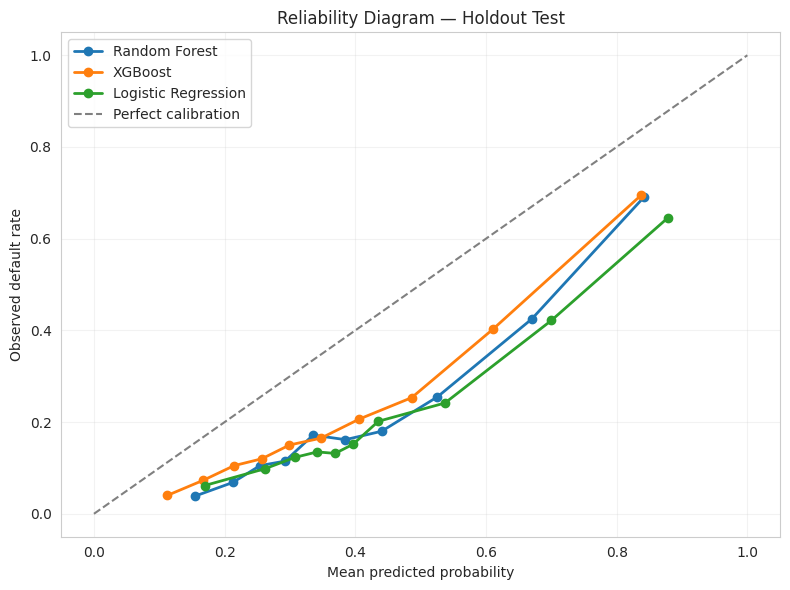

Kết luận calibration:
- Brier Score và reliability diagram dùng để đánh giá độ tin cậy của xác suất dự báo.
- Nếu triển khai thực tế, cần hiệu chỉnh xác suất bằng Platt Scaling/Isotonic Regression trên validation set riêng.
- Trong khóa luận, PD nên được diễn giải thận trọng như điểm rủi ro tương đối, không phải xác suất vỡ nợ tuyệt đối đã calibrated.


In [26]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — CALIBRATION DIAGNOSTIC: BRIER SCORE + RELIABILITY DIAGRAM
# ══════════════════════════════════════════════════════════════════════════════
# Mục đích: kiểm tra mức độ đáng tin của xác suất dự báo. RF/XGBoost có thể
# phân biệt tốt nhưng không mặc định calibrated tốt. Vì vậy, PD trong nghiên cứu
# nên được hiểu chủ yếu như điểm rủi ro tương đối nếu chưa calibration production.

base_rate = y_test.mean()
brier_naive = base_rate * (1 - base_rate)

calib_rows = []
for r in final_results:
    bs = brier_score_loss(y_test, r["y_prob"])
    bss = 1 - bs / brier_naive if brier_naive > 0 else np.nan
    calib_rows.append({
        "Model": r["Model"],
        "Brier Score": bs,
        "Brier Skill Score vs naive": bss,
    })

calibration_df = pd.DataFrame(calib_rows).sort_values("Brier Score").reset_index(drop=True)
display(calibration_df)

plt.figure(figsize=(8, 6))
for r in final_results:
    if r["Model"] == "Dummy Baseline":
        continue
    frac_pos, mean_pred = calibration_curve(
        y_test, r["y_prob"], n_bins=10, strategy="quantile"
    )
    plt.plot(mean_pred, frac_pos, marker="o", lw=2, label=r["Model"])

plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
plt.title("Reliability Diagram — Holdout Test")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed default rate")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Kết luận calibration:")
print("- Brier Score và reliability diagram dùng để đánh giá độ tin cậy của xác suất dự báo.")
print("- Nếu triển khai thực tế, cần hiệu chỉnh xác suất bằng Platt Scaling/Isotonic Regression trên validation set riêng.")
print("- Trong khóa luận, PD nên được diễn giải thận trọng như điểm rủi ro tương đối, không phải xác suất vỡ nợ tuyệt đối đã calibrated.")


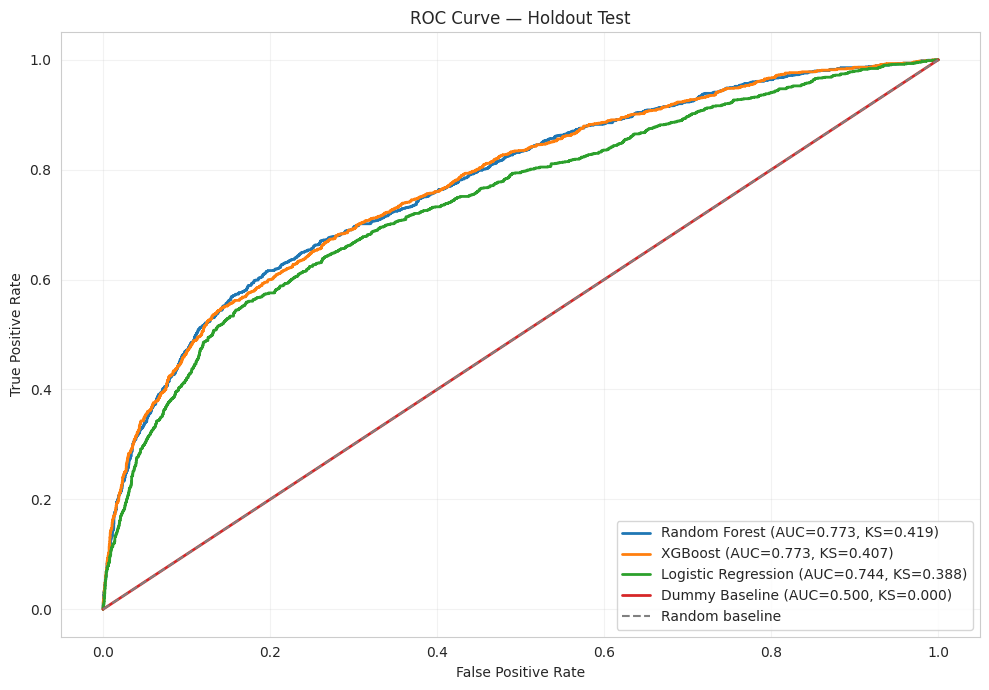

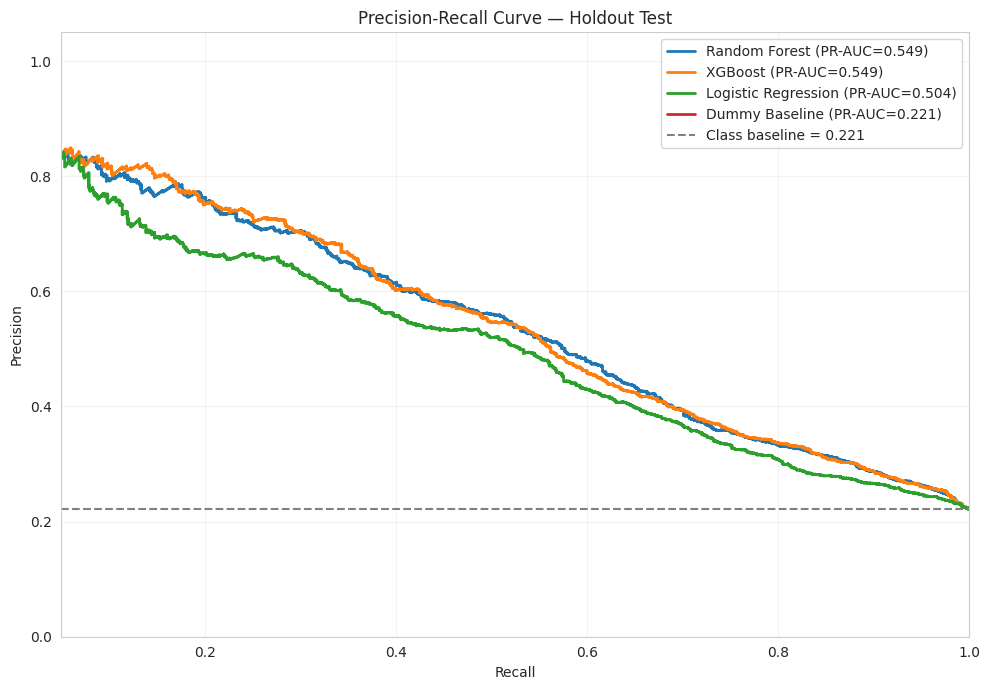

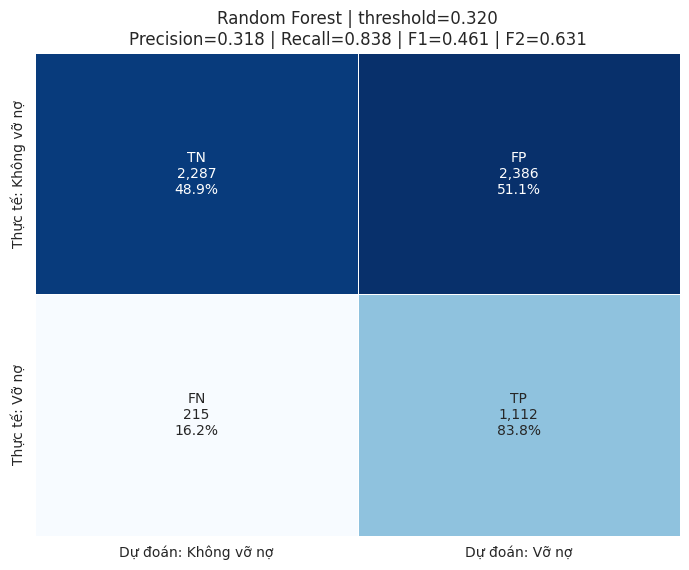


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.9141    0.4894    0.6375      4673
           1     0.3179    0.8380    0.4609      1327

    accuracy                         0.5665      6000
   macro avg     0.6160    0.6637    0.5492      6000
weighted avg     0.7822    0.5665    0.5984      6000



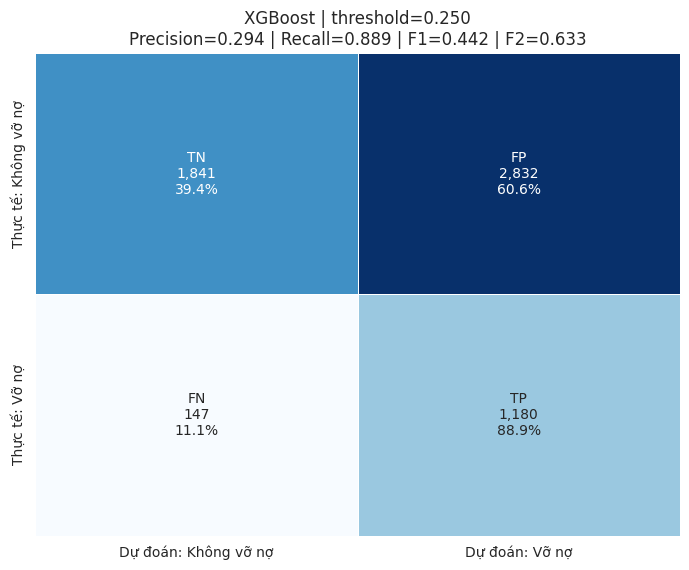


=== XGBoost ===
              precision    recall  f1-score   support

           0     0.9261    0.3940    0.5528      4673
           1     0.2941    0.8892    0.4420      1327

    accuracy                         0.5035      6000
   macro avg     0.6101    0.6416    0.4974      6000
weighted avg     0.7863    0.5035    0.5283      6000



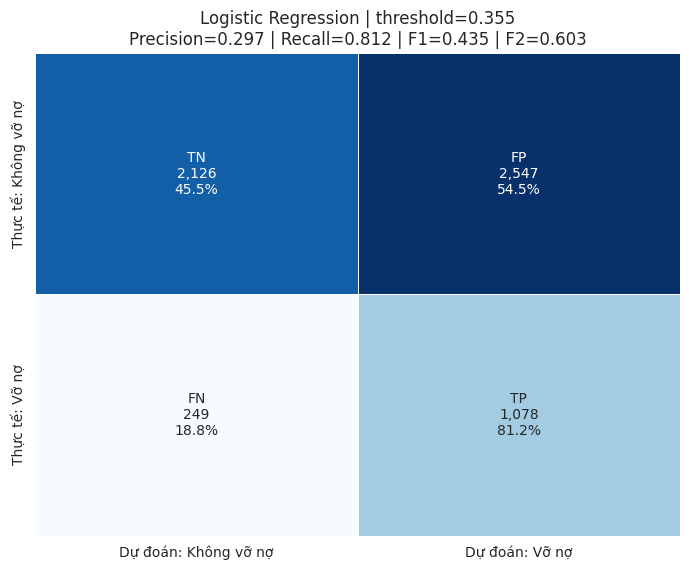


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.8952    0.4550    0.6033      4673
           1     0.2974    0.8124    0.4354      1327

    accuracy                         0.5340      6000
   macro avg     0.5963    0.6337    0.5193      6000
weighted avg     0.7629    0.5340    0.5662      6000



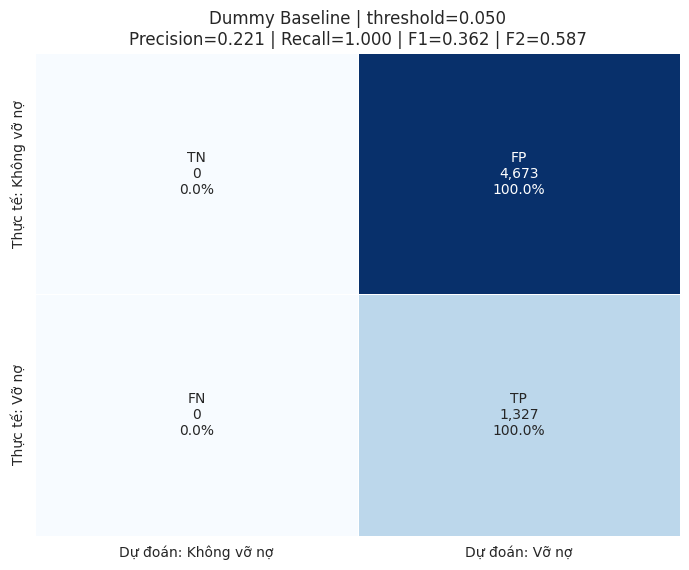


=== Dummy Baseline ===
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000      4673
           1     0.2212    1.0000    0.3622      1327

    accuracy                         0.2212      6000
   macro avg     0.1106    0.5000    0.1811      6000
weighted avg     0.0489    0.2212    0.0801      6000



In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 11 — ROC + PR CURVES + CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════════════════════
plt.figure(figsize=(10, 7))
for r in final_results:
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    plt.plot(fpr, tpr, lw=2,
             label=f'{r["Model"]} (AUC={r["ROC-AUC"]:.3f}, KS={r["KS Statistic"]:.3f})')
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random baseline")
plt.title("ROC Curve — Holdout Test")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

MIN_RECALL_TO_PLOT = 0.05
baseline_precision = y_test.mean()

plt.figure(figsize=(10, 7))
for r in final_results:
    precision, recall, _ = precision_recall_curve(y_test, r["y_prob"])

    plot_df = (
        pd.DataFrame({"Recall": recall, "Precision": precision})
        .drop_duplicates()
        .sort_values("Recall")
    )
    plot_df = plot_df[plot_df["Recall"] >= MIN_RECALL_TO_PLOT]

    plt.step(plot_df["Recall"], plot_df["Precision"], where="post", lw=2,
             label=f'{r["Model"]} (PR-AUC={r["PR-AUC"]:.3f})')

plt.axhline(baseline_precision, linestyle="--", color="gray",
            label=f"Class baseline = {baseline_precision:.3f}")
plt.title("Precision-Recall Curve — Holdout Test")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(MIN_RECALL_TO_PLOT, 1.0)
plt.ylim(0.0, 1.05)
plt.legend(loc="upper right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

for r in final_results:
    cm = r["cm"]
    tn, fp, fn, tp = cm.ravel()

    row_pct = cm / cm.sum(axis=1, keepdims=True)
    labels = np.array([
        [f"TN\n{tn:,}\n{row_pct[0,0]:.1%}", f"FP\n{fp:,}\n{row_pct[0,1]:.1%}"],
        [f"FN\n{fn:,}\n{row_pct[1,0]:.1%}", f"TP\n{tp:,}\n{row_pct[1,1]:.1%}"],
    ])

    plt.figure(figsize=(7, 5.8))
    sns.heatmap(
        cm, annot=labels, fmt="", cmap="Blues", cbar=False,
        xticklabels=["Dự đoán: Không vỡ nợ", "Dự đoán: Vỡ nợ"],
        yticklabels=["Thực tế: Không vỡ nợ", "Thực tế: Vỡ nợ"],
        linewidths=0.5, linecolor="white"
    )
    plt.title(
        f'{r["Model"]} | threshold={r["Threshold"]:.3f}\n'
        f'Precision={r["Precision"]:.3f} | Recall={r["Recall"]:.3f} | '
        f'F1={r["F1-score"]:.3f} | F2={r["F2-score"]:.3f}'
    )
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {r['Model']} ===")
    print(classification_report(y_test, r["y_pred"], digits=4, zero_division=0))


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 12 — CHỌN MODEL TỐT NHẤT + CHUẨN BỊ SHAP
# ══════════════════════════════════════════════════════════════════════════════
best_row        = results_df.sort_values(["ROC-AUC","F2-score"],ascending=False).iloc[0]
best_model_name = best_row["Model"]
best_pipeline   = best_estimators[best_model_name]

print("Best model:", best_model_name)

fitted_preprocessor = best_pipeline.named_steps["preprocessor"]
fitted_model        = best_pipeline.named_steps["model"]

SHAP_PER_CLASS = 150
n0 = min(SHAP_PER_CLASS, int((y_test == 0).sum()))
n1 = min(SHAP_PER_CLASS, int((y_test == 1).sum()))

idx0 = y_test[y_test == 0].sample(n0, random_state=SEED).index
idx1 = y_test[y_test == 1].sample(n1, random_state=SEED).index
X_shap_raw = X_test.loc[idx0.union(idx1)]
y_shap     = y_test.loc[idx0.union(idx1)]

X_shap_t  = fitted_preprocessor.transform(X_shap_raw)

try:
    raw_feature_names = list(fitted_preprocessor.get_feature_names_out())
except AttributeError:
    num_names = [f"num__{c}" for c in numeric_cols]
    ohe       = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_names = [f"cat__{n}" for n in ohe.get_feature_names(CATEGORICAL_COLS)]
    raw_feature_names = num_names + cat_names

display_feature_names = [friendly_name(n) for n in raw_feature_names]

X_shap_df       = pd.DataFrame(X_shap_t, columns=raw_feature_names,
                                index=X_shap_raw.index)
X_shap_display  = pd.DataFrame(X_shap_t, columns=display_feature_names,
                                index=X_shap_raw.index)

print(f"[FIX-5a] SHAP sample: {n0} non-default + {n1} default = {len(X_shap_df)} rows")

Best model: Random Forest
[FIX-5a] SHAP sample: 150 non-default + 150 default = 300 rows


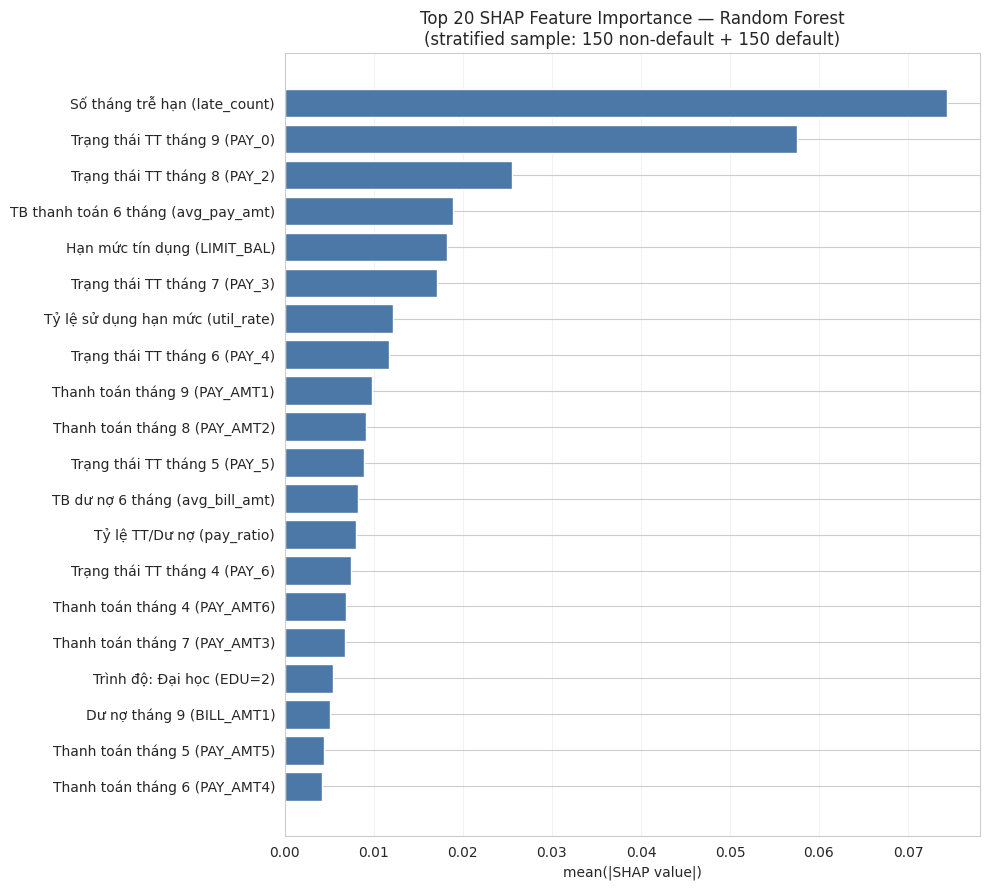

,mean_abs_shap
Số tháng trễ hạn (late_count),0.074368
Trạng thái TT tháng 9 (PAY_0),0.057564
Trạng thái TT tháng 8 (PAY_2),0.025565
TB thanh toán 6 tháng (avg_pay_amt),0.018834
Hạn mức tín dụng (LIMIT_BAL),0.018171
Trạng thái TT tháng 7 (PAY_3),0.017142
Tỷ lệ sử dụng hạn mức (util_rate),0.012193
Trạng thái TT tháng 6 (PAY_4),0.011646
Thanh toán tháng 9 (PAY_AMT1),0.009752
Thanh toán tháng 8 (PAY_AMT2),0.009148



── Beeswarm: hướng và mức độ đóng góp của từng biến vào dự báo ──


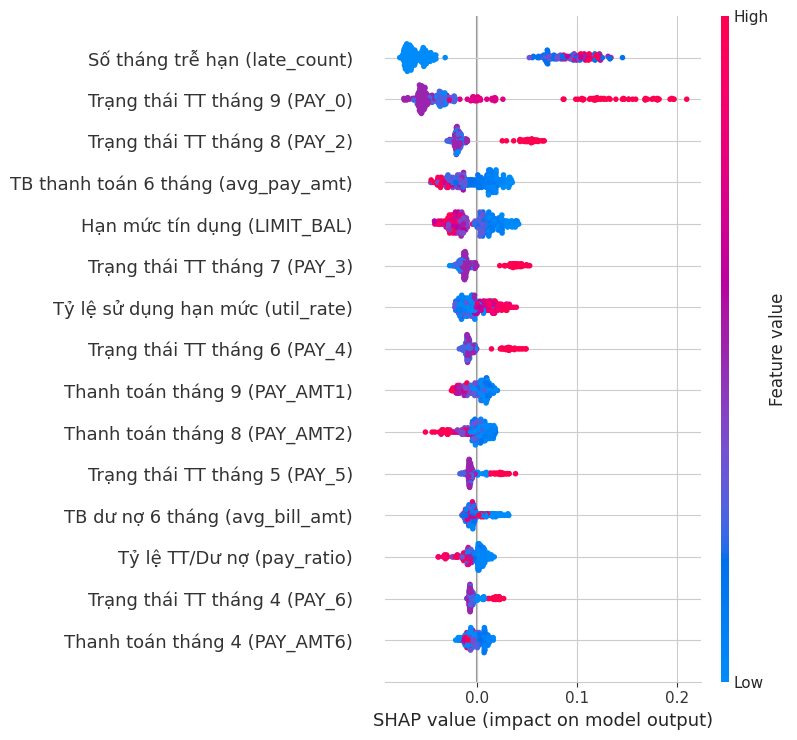


── SHAP Dependence Plots — top 3 biến quan trọng ──
Trục X dùng giá trị gốc dễ hiểu; trục Y là SHAP value cho xác suất vỡ nợ.

  Biến: Số tháng trễ hạn (late_count)


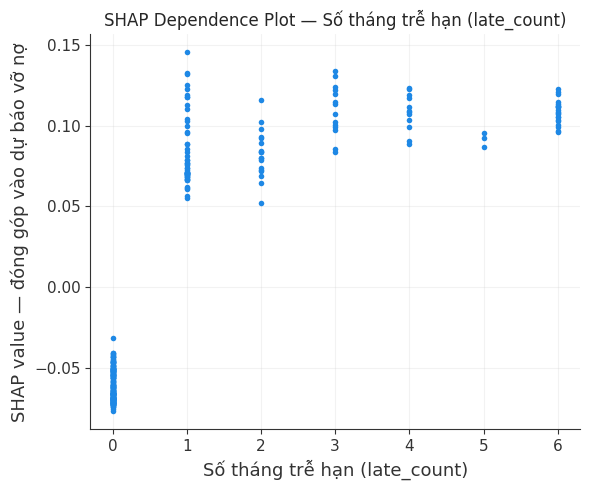


  Biến: Trạng thái TT tháng 9 (PAY_0)


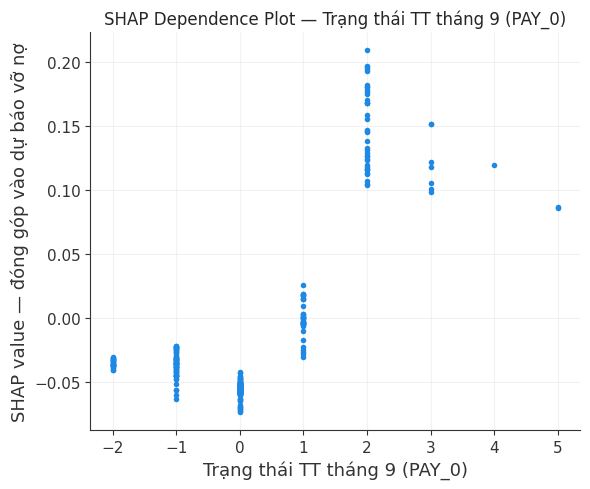


  Biến: Trạng thái TT tháng 8 (PAY_2)


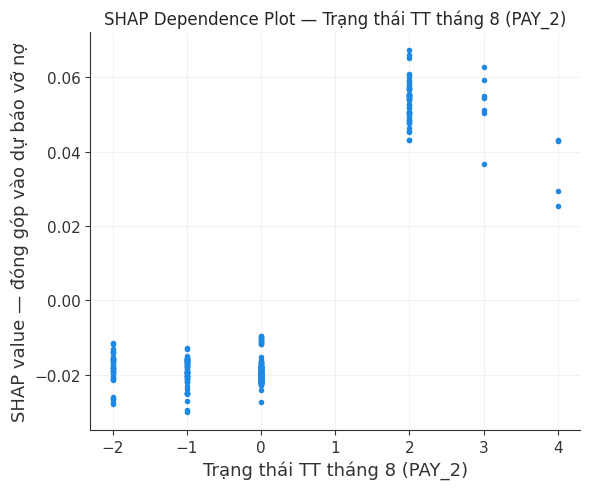

In [29]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 13 — SHAP: BAR CHART + BEESWARM + DEPENDENCE PLOTS
# ══════════════════════════════════════════════════════════════════════════════
if best_model_name in ["Random Forest", "XGBoost"]:
    explainer   = shap.TreeExplainer(fitted_model)
    shap_values = explainer.shap_values(X_shap_df)
else:
    X_train_t  = fitted_preprocessor.transform(X_train)
    X_train_df = pd.DataFrame(X_train_t, columns=raw_feature_names)
    background = shap.sample(X_train_df, 200, random_state=SEED)
    explainer  = shap.LinearExplainer(fitted_model, background)
    shap_values = explainer.shap_values(X_shap_df)

# Ensure shap_matrix is (n_samples, n_features) for the positive class (class 1)
if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_matrix = shap_values[:, :, 1]
else:
    shap_matrix = shap_values

expected_val = explainer.expected_value
if isinstance(expected_val, (list, np.ndarray)):
    expected_val = float(np.atleast_1d(expected_val)[1])
else:
    expected_val = float(expected_val)

# ── 13a. Global importance bar chart  ────────────────────────
mean_abs_shap   = np.abs(shap_matrix).mean(axis=0)
shap_importance = (
    pd.Series(mean_abs_shap, index=display_feature_names)
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 9))
plt.barh(shap_importance.index[::-1], shap_importance.values[::-1], color="#4C78A8")
plt.title(f"Top 20 SHAP Feature Importance — {best_model_name}\n"
          f"(stratified sample: {n0} non-default + {n1} default)")
plt.xlabel("mean(|SHAP value|)")
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()
display(shap_importance.to_frame("mean_abs_shap"))

# ── 13b. Beeswarm ──────────────────────────────────────
print("\n── Beeswarm: hướng và mức độ đóng góp của từng biến vào dự báo ──")
shap.summary_plot(shap_matrix, X_shap_display, max_display=15, show=True)

# ── 13c. Dependence plots: top 3 features
X_shap_dependence = X_shap_df.copy()
X_shap_dependence.columns = display_feature_names

for raw_name, display_name in zip(raw_feature_names, display_feature_names):
    if raw_name.startswith("num__"):
        original_col = raw_name.replace("num__", "", 1)
        if original_col in X_shap_raw.columns:
            X_shap_dependence[display_name] = X_shap_raw[original_col].values

top3_raw = (
    pd.Series(mean_abs_shap, index=raw_feature_names)
    .sort_values(ascending=False)
    .head(3)
    .index
    .tolist()
)

print("\n── SHAP Dependence Plots — top 3 biến quan trọng ──")
print("Trục X dùng giá trị gốc dễ hiểu; trục Y là SHAP value cho xác suất vỡ nợ.")
for feat_raw in top3_raw:
    feat_display = friendly_name(feat_raw)
    print(f"\n  Biến: {feat_display}")

    shap.dependence_plot(
        feat_display,
        shap_matrix,
        X_shap_dependence,
        feature_names=display_feature_names,
        interaction_index=None,   # tránh colorbar dùng tên kỹ thuật khó đọc
        show=False
    )
    plt.title(f"SHAP Dependence Plot — {feat_display}")
    plt.xlabel(feat_display)
    plt.ylabel("SHAP value — đóng góp vào dự báo vỡ nợ")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


---
## Phần RQ3 — Risk scoring, decision table và căn cứ minh bạch cho quyết định tín dụng

Phần này chuyển đầu ra kỹ thuật thành framework hỗ trợ quyết định tín dụng qua 5 bước:
1. Xác định ngưỡng phân nhóm rủi ro có căn cứ từ **cost matrix** (FN/FP).
2. Phân nhóm và lập **decision table** với rationale rõ ràng.
3. **SHAP theo nhóm rủi ro** — giải thích tại sao khách hàng rơi vào từng nhóm.
4. **Waterfall plots** cho 3 hồ sơ đại diện (low/high/edge-case medium).
5. **Thảo luận giới hạn** triển khai trong thực tiễn ngân hàng.


In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 14 — NGƯỠNG PHÂN NHÓM CÓ CĂN CỨ TỪ COST MATRIX
# ══════════════════════════════════════════════════════════════════════════════

COST_FN = 5   # chi phí tương đối của False Negative (cho vay người sẽ vỡ nợ)
COST_FP = 1   # chi phí tương đối của False Positive (từ chối người tốt)

# high_risk_threshold từ F2 (ưu tiên recall)
# đây là ngưỡng hoạt động (operational threshold)
final_model_name = best_model_name
final_pipeline   = best_estimators[final_model_name]

high_risk_threshold = float(
    threshold_summary.loc[
        threshold_summary["Model"] == final_model_name,
        "Best Threshold (F2)"
    ].iloc[0]
)

# Ngưỡng cost-optimal (dùng làm Low-risk boundary)
cost_optimal_threshold = COST_FP / (COST_FP + COST_FN)

# Low-risk: PD < cost_optimal (khách hàng rõ ràng an toàn theo cost matrix)
# Medium-risk: cost_optimal <= PD < high_risk_threshold
# High-risk: PD >= high_risk_threshold (ngưỡng F2-optimized từ train OOF)
low_risk_threshold = cost_optimal_threshold

# Đảm bảo logic nhất quán
if low_risk_threshold >= high_risk_threshold:
    low_risk_threshold = high_risk_threshold * 0.5
    print("[WARNING] cost_optimal >= high_risk_threshold; đặt low_threshold = high/2")

print("[FIX-6] Ngưỡng phân nhóm rủi ro:")
print(f"  Cost matrix: FN={COST_FN}, FP={COST_FP}")
print(f"  Cost-optimal threshold: {cost_optimal_threshold:.4f}"
      f" = {COST_FP}/({COST_FP}+{COST_FN})")
print(f"  Low-risk  : PD < {low_risk_threshold:.4f}")
print(f"  Medium-risk: {low_risk_threshold:.4f} ≤ PD < {high_risk_threshold:.4f}")
print(f"  High-risk : PD ≥ {high_risk_threshold:.4f} (F2-optimized)")

train_pd = final_pipeline.predict_proba(X_train)[:, 1]
test_pd  = final_pipeline.predict_proba(X_test)[:, 1]

def assign_risk_level(pd_score, low_t, high_t):
    if pd_score < low_t:
        return "Low Risk"
    elif pd_score < high_t:
        return "Medium Risk"
    return "High Risk"

decision_table = pd.DataFrame({
    "Nhóm rủi ro":     ["Low Risk", "Medium Risk", "High Risk"],
    "Khoảng PD":       [
        f"PD < {low_risk_threshold:.3f}",
        f"{low_risk_threshold:.3f} ≤ PD < {high_risk_threshold:.3f}",
        f"PD ≥ {high_risk_threshold:.3f}",
    ],
    "Khuyến nghị":     ["Phê duyệt", "Xem xét thủ công / Yêu cầu bổ sung hồ sơ",
                        "Từ chối / Chuyển lên Hội đồng tín dụng"],
    "Căn cứ":          [
        f"PD dưới ngưỡng cost-optimal ({COST_FP}/({COST_FP}+{COST_FN})={cost_optimal_threshold:.3f}): "
        "expected loss thấp hơn chi phí cơ hội của việc từ chối.",
        "PD nằm trong vùng không chắc chắn giữa hai ngưỡng: "
        "cần đánh giá định tính bổ sung (tài sản đảm bảo, lịch sử giao dịch, ...).",
        f"PD vượt ngưỡng F2-optimized ({high_risk_threshold:.3f}) được tối ưu trên "
        "out-of-fold train set, ưu tiên recall để giảm tổn thất tín dụng.",
    ],
})
display(decision_table)

[FIX-6] Ngưỡng phân nhóm rủi ro:
  Cost matrix: FN=5, FP=1
  Cost-optimal threshold: 0.1667 = 1/(1+5)
  Low-risk  : PD < 0.1667
  Medium-risk: 0.1667 ≤ PD < 0.3200
  High-risk : PD ≥ 0.3200 (F2-optimized)


,Nhóm rủi ro,Khoảng PD,Khuyến nghị,Căn cứ
0,Low Risk,PD < 0.167,Phê duyệt,PD dưới ngưỡng cost-optimal (1/(1+5)=0.167): e...
1,Medium Risk,0.167 ≤ PD < 0.320,Xem xét thủ công / Yêu cầu bổ sung hồ sơ,PD nằm trong vùng không chắc chắn giữa hai ngư...
2,High Risk,PD ≥ 0.320,Từ chối / Chuyển lên Hội đồng tín dụng,PD vượt ngưỡng F2-optimized (0.320) được tối ư...


,Risk Level,n_customers,avg_PD,median_PD,observed_default_rate
0,Low Risk,380,0.140606,0.144180,0.042105
1,Medium Risk,2122,0.248273,0.250166,0.093779
2,High Risk,3498,0.539498,0.482508,0.317896


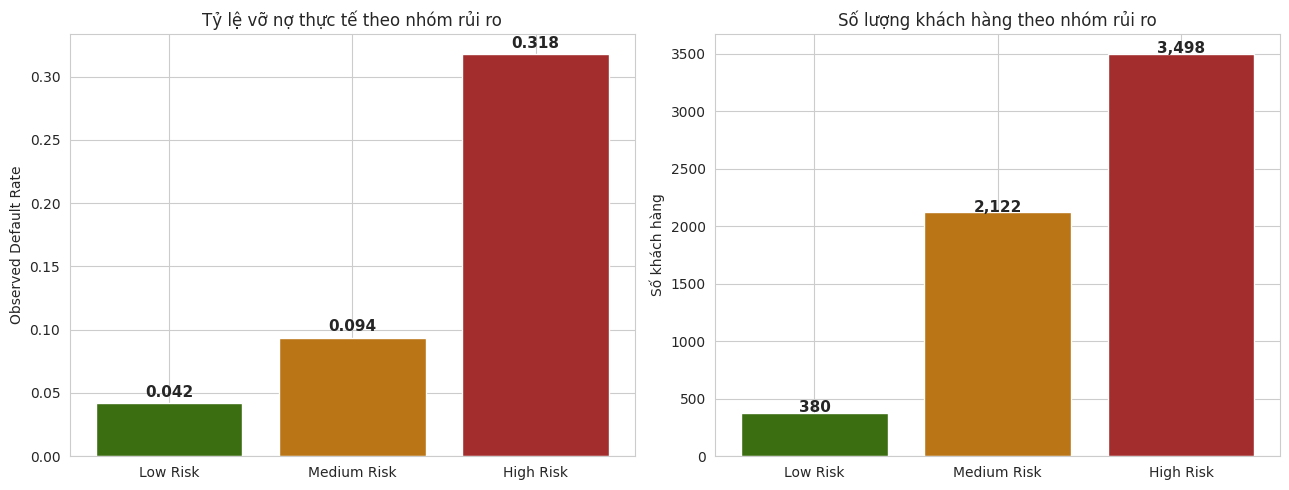

In [31]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 15 — PHÂN NHÓM RỦI RO TRÊN HOLDOUT TEST + TÓM TẮT
# ══════════════════════════════════════════════════════════════════════════════
rq3_test_df = X_test.copy().reset_index(drop=True)
rq3_test_df["y_true"]     = y_test.reset_index(drop=True).astype(int).values
rq3_test_df["PD"]         = test_pd
rq3_test_df["Risk Level"] = rq3_test_df["PD"].apply(
    lambda x: assign_risk_level(x, low_risk_threshold, high_risk_threshold)
)

risk_level_order = pd.CategoricalDtype(
    categories=["Low Risk", "Medium Risk", "High Risk"], ordered=True
)
rq3_test_df["Risk Level"] = rq3_test_df["Risk Level"].astype(risk_level_order)

risk_summary = (
    rq3_test_df.groupby("Risk Level", observed=False)
    .agg(
        n_customers            =("PD",     "size"),
        avg_PD                 =("PD",     "mean"),
        median_PD              =("PD",     "median"),
        observed_default_rate  =("y_true", "mean"),
    )
    .reset_index()
)
display(risk_summary)

# Biểu đồ default rate theo nhóm
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#3B6D11", "#BA7517", "#A32D2D"]
axes[0].bar(risk_summary["Risk Level"].astype(str),
            risk_summary["observed_default_rate"], color=colors)
axes[0].set_title("Tỷ lệ vỡ nợ thực tế theo nhóm rủi ro")
axes[0].set_ylabel("Observed Default Rate")
for i, v in enumerate(risk_summary["observed_default_rate"]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

axes[1].bar(risk_summary["Risk Level"].astype(str),
            risk_summary["n_customers"], color=colors)
axes[1].set_title("Số lượng khách hàng theo nhóm rủi ro")
axes[1].set_ylabel("Số khách hàng")
for i, v in enumerate(risk_summary["n_customers"]):
    axes[1].text(i, v + 5, f"{v:,}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — 95% CI CHO TỶ LỆ VỠ NỢ THEO NHÓM RỦI RO
# ══════════════════════════════════════════════════════════════════════════════
def proportion_wilson_ci(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    phat = k / n
    denom = 1 + z**2 / n
    center = (phat + z**2 / (2*n)) / denom
    margin = z * np.sqrt((phat*(1-phat) + z**2/(4*n)) / n) / denom
    return center - margin, center + margin

ci_rows = []
for level in ["Low Risk", "Medium Risk", "High Risk"]:
    sub = rq3_test_df[rq3_test_df["Risk Level"].astype(str) == level]
    n = len(sub)
    k = int(sub["y_true"].sum())
    lo, hi = proportion_wilson_ci(k, n)
    ci_rows.append({
        "Risk Level": level,
        "n": n,
        "defaults": k,
        "observed_default_rate": k/n if n else np.nan,
        "95% CI lower": lo,
        "95% CI upper": hi,
    })

risk_group_ci = pd.DataFrame(ci_rows)
display(risk_group_ci)
print("CI giúp diễn giải phân nhóm rủi ro thận trọng hơn, đặc biệt khi một nhóm có số quan sát nhỏ.")


,Risk Level,n,defaults,observed_default_rate,95% CI lower,95% CI upper
0,Low Risk,380,16,0.042105,0.026081,0.067295
1,Medium Risk,2122,199,0.093779,0.082099,0.106928
2,High Risk,3498,1112,0.317896,0.302671,0.333520


CI giúp diễn giải phân nhóm rủi ro thận trọng hơn, đặc biệt khi một nhóm có số quan sát nhỏ.


In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL — SENSITIVITY ANALYSIS: COST RATIO FN:FP
# ══════════════════════════════════════════════════════════════════════════════
# Kiểm tra ngưỡng cost-optimal thay đổi thế nào khi giả định chi phí FN:FP thay đổi.
# High-risk threshold vẫn giữ theo F2-optimized threshold trên OOF train.

cost_ratios = [3, 5, 7, 10]  # C_FN : C_FP, với C_FP = 1
sens_rows = []
y_test_arr = np.asarray(y_test)

for cfn in cost_ratios:
    cfp = 1
    t_cost = cfp / (cfp + cfn)
    low_t_sens = t_cost
    high_t_sens = high_risk_threshold
    if low_t_sens >= high_t_sens:
        low_t_sens = high_t_sens * 0.5

    risk_sens = pd.Series(test_pd).apply(
        lambda x: "Low" if x < low_t_sens else ("Medium" if x < high_t_sens else "High")
    )

    row = {
        "FN:FP Ratio": f"{cfn}:1",
        "Cost-optimal t*": t_cost,
        "Low n": int((risk_sens == "Low").sum()),
        "Medium n": int((risk_sens == "Medium").sum()),
        "High n": int((risk_sens == "High").sum()),
        "Low default rate": y_test_arr[risk_sens == "Low"].mean() if (risk_sens == "Low").sum() else np.nan,
        "Medium default rate": y_test_arr[risk_sens == "Medium"].mean() if (risk_sens == "Medium").sum() else np.nan,
        "High default rate": y_test_arr[risk_sens == "High"].mean() if (risk_sens == "High").sum() else np.nan,
    }
    sens_rows.append(row)

sensitivity_df = pd.DataFrame(sens_rows)
display(sensitivity_df)
print("Diễn giải: khi FN:FP tăng, ngưỡng cost-optimal giảm, tức mô hình thận trọng hơn và ít xếp khách hàng vào Low Risk hơn.")


,FN:FP Ratio,Cost-optimal t*,Low n,Medium n,High n,Low default rate,Medium default rate,High default rate
0,3:1,0.250000,1435,1067,3498,0.064111,0.115276,0.317896
1,5:1,0.166667,380,2122,3498,0.042105,0.093779,0.317896
2,7:1,0.125000,78,2424,3498,0.025641,0.087871,0.317896
3,10:1,0.090909,3,2499,3498,0.000000,0.086034,0.317896


Diễn giải: khi FN:FP tăng, ngưỡng cost-optimal giảm, tức mô hình thận trọng hơn và ít xếp khách hàng vào Low Risk hơn.


In [34]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 16 — SHAP THEO NHÓM RỦI RO
# ══════════════════════════════════════════════════════════════════════════════
decision_preprocessor = final_pipeline.named_steps["preprocessor"]
decision_model        = final_pipeline.named_steps["model"]

X_test_t_full = decision_preprocessor.transform(X_test)

# Dùng raw_feature_names (kỹ thuật) cho SHAP computation
# Dùng display_feature_names (thân thiện) cho visualisation
X_test_t_full_df = pd.DataFrame(
    X_test_t_full, columns=raw_feature_names, index=rq3_test_df.index
)

if final_model_name in ["Random Forest", "XGBoost"]:
    decision_explainer   = shap.TreeExplainer(decision_model)
    decision_shap_values = decision_explainer.shap_values(X_test_t_full_df)
else:
    X_train_t_full   = decision_preprocessor.transform(X_train)
    X_train_t_full_df = pd.DataFrame(X_train_t_full, columns=raw_feature_names)
    bg = shap.sample(X_train_t_full_df, 200, random_state=SEED)
    decision_explainer   = shap.LinearExplainer(decision_model, bg)
    decision_shap_values = decision_explainer.shap_values(X_test_t_full_df)

# Ensure decision_shap_matrix is (n_samples, n_features) for the positive class (class 1)
if isinstance(decision_shap_values, list):
    # This typically happens when TreeExplainer returns [shap_values_class0, shap_values_class1]
    # We want shap_values_class1 (positive class)
    decision_shap_matrix = decision_shap_values[1]
elif isinstance(decision_shap_values, np.ndarray) and decision_shap_values.ndim == 3:
    # This happens if explainer.shap_values returns (n_samples, n_features, n_classes) directly
    # We want shap_values for class 1 (positive class) by selecting the last dimension's index 1
    decision_shap_matrix = decision_shap_values[:, :, 1]
else:
    # Fallback for regression or if shap_values is already (n_samples, n_features)
    decision_shap_matrix = decision_shap_values

decision_shap_df = pd.DataFrame(
    decision_shap_matrix, columns=raw_feature_names, index=rq3_test_df.index
)

def top_group_drivers(group_name, top_n=8):
    idx        = rq3_test_df.index[rq3_test_df["Risk Level"].astype(str) == group_name]
    group_shap = decision_shap_df.loc[idx]
    mean_signed = group_shap.mean()
    mean_abs    = group_shap.abs().mean()
    df_out = pd.DataFrame({
        "Tên biến":       [friendly_name(n) for n in mean_signed.index],
        "mean_SHAP":      mean_signed.values,
        "mean_abs_SHAP":  mean_abs.values,
    }).sort_values("mean_abs_SHAP", ascending=False).head(top_n).reset_index(drop=True)
    return df_out

group_driver_results = {}
for g in ["Low Risk", "Medium Risk", "High Risk"]:
    group_driver_results[g] = top_group_drivers(g)
    print(f"\n===== Top SHAP drivers — {g} =====")
    display(group_driver_results[g])


===== Top SHAP drivers — Low Risk =====


,Tên biến,mean_SHAP,mean_abs_SHAP
0,Số tháng trễ hạn (late_count),-0.064165,0.064165
1,Trạng thái TT tháng 9 (PAY_0),-0.048873,0.048873
2,TB thanh toán 6 tháng (avg_pay_amt),-0.030064,0.030064
3,Hạn mức tín dụng (LIMIT_BAL),-0.024763,0.025319
4,Thanh toán tháng 8 (PAY_AMT2),-0.019791,0.020393
5,Trạng thái TT tháng 8 (PAY_2),-0.019604,0.019604
6,Tỷ lệ sử dụng hạn mức (util_rate),-0.018185,0.018374
7,Thanh toán tháng 9 (PAY_AMT1),-0.016527,0.017635



===== Top SHAP drivers — Medium Risk =====


,Tên biến,mean_SHAP,mean_abs_SHAP
0,Số tháng trễ hạn (late_count),-0.061777,0.063964
1,Trạng thái TT tháng 9 (PAY_0),-0.048568,0.048576
2,TB thanh toán 6 tháng (avg_pay_amt),-0.016518,0.020619
3,Trạng thái TT tháng 8 (PAY_2),-0.019990,0.019990
4,Hạn mức tín dụng (LIMIT_BAL),-0.012484,0.018857
5,Tỷ lệ sử dụng hạn mức (util_rate),-0.004394,0.016483
6,Trạng thái TT tháng 7 (PAY_3),-0.014029,0.014086
7,Thanh toán tháng 9 (PAY_AMT1),-0.006179,0.012067



===== Top SHAP drivers — High Risk =====


,Tên biến,mean_SHAP,mean_abs_SHAP
0,Số tháng trễ hạn (late_count),0.024928,0.077091
1,Trạng thái TT tháng 9 (PAY_0),-0.005758,0.056526
2,Trạng thái TT tháng 8 (PAY_2),-0.001112,0.027680
3,Trạng thái TT tháng 7 (PAY_3),0.000432,0.018130
4,Hạn mức tín dụng (LIMIT_BAL),0.004893,0.018027
5,TB thanh toán 6 tháng (avg_pay_amt),0.007300,0.017104
6,Trạng thái TT tháng 6 (PAY_4),0.000230,0.012873
7,Tỷ lệ sử dụng hạn mức (util_rate),0.002279,0.010193


In [35]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 17 —  NARRATIVE NHÓM RỦI RO
# ══════════════════════════════════════════════════════════════════════════════
def describe_risk_group(group_name, top_n=5):
    df_drivers  = group_driver_results[group_name].head(top_n)
    pos_drivers = df_drivers[df_drivers["mean_SHAP"] > 0]["Tên biến"].tolist()
    neg_drivers = df_drivers[df_drivers["mean_SHAP"] < 0]["Tên biến"].tolist()
    stats       = risk_summary.loc[
        risk_summary["Risk Level"].astype(str) == group_name
    ].iloc[0]

    lines = [f"Nhóm {group_name} ({int(stats['n_customers'])} khách hàng):"]
    if pos_drivers:
        lines.append(
            f"  Các tín hiệu ĐÓNG GÓP LÀM TĂNG dự báo rủi ro: "
            + "; ".join(pos_drivers[:3]) + "."
        )
    if neg_drivers:
        lines.append(
            f"  Các tín hiệu ĐÓNG GÓP LÀM GIẢM dự báo rủi ro: "
            + "; ".join(neg_drivers[:3]) + "."
        )
    lines.append(
        f"  PD trung bình = {stats['avg_PD']:.3f} | "
        f"Tỷ lệ vỡ nợ quan sát = {stats['observed_default_rate']:.3f}"
    )
    return "\n".join(lines)

print("Narrative nhóm rủi ro (tên feature thân thiện):")
print("=" * 65)
for g in ["Low Risk", "Medium Risk", "High Risk"]:
    print(describe_risk_group(g))
    print()

Narrative nhóm rủi ro (tên feature thân thiện):
Nhóm Low Risk (380 khách hàng):
  Các tín hiệu ĐÓNG GÓP LÀM GIẢM dự báo rủi ro: Số tháng trễ hạn (late_count); Trạng thái TT tháng 9 (PAY_0); TB thanh toán 6 tháng (avg_pay_amt).
  PD trung bình = 0.141 | Tỷ lệ vỡ nợ quan sát = 0.042

Nhóm Medium Risk (2122 khách hàng):
  Các tín hiệu ĐÓNG GÓP LÀM GIẢM dự báo rủi ro: Số tháng trễ hạn (late_count); Trạng thái TT tháng 9 (PAY_0); TB thanh toán 6 tháng (avg_pay_amt).
  PD trung bình = 0.248 | Tỷ lệ vỡ nợ quan sát = 0.094

Nhóm High Risk (3498 khách hàng):
  Các tín hiệu ĐÓNG GÓP LÀM TĂNG dự báo rủi ro: Số tháng trễ hạn (late_count); Trạng thái TT tháng 7 (PAY_3); Hạn mức tín dụng (LIMIT_BAL).
  Các tín hiệu ĐÓNG GÓP LÀM GIẢM dự báo rủi ro: Trạng thái TT tháng 9 (PAY_0); Trạng thái TT tháng 8 (PAY_2).
  PD trung bình = 0.539 | Tỷ lệ vỡ nợ quan sát = 0.318




────────────────────────────────────────────────────────────
  Low Risk — hồ sơ rủi ro thấp nhất
  PD dự báo = 0.0856 | Thực tế vỡ nợ = 0


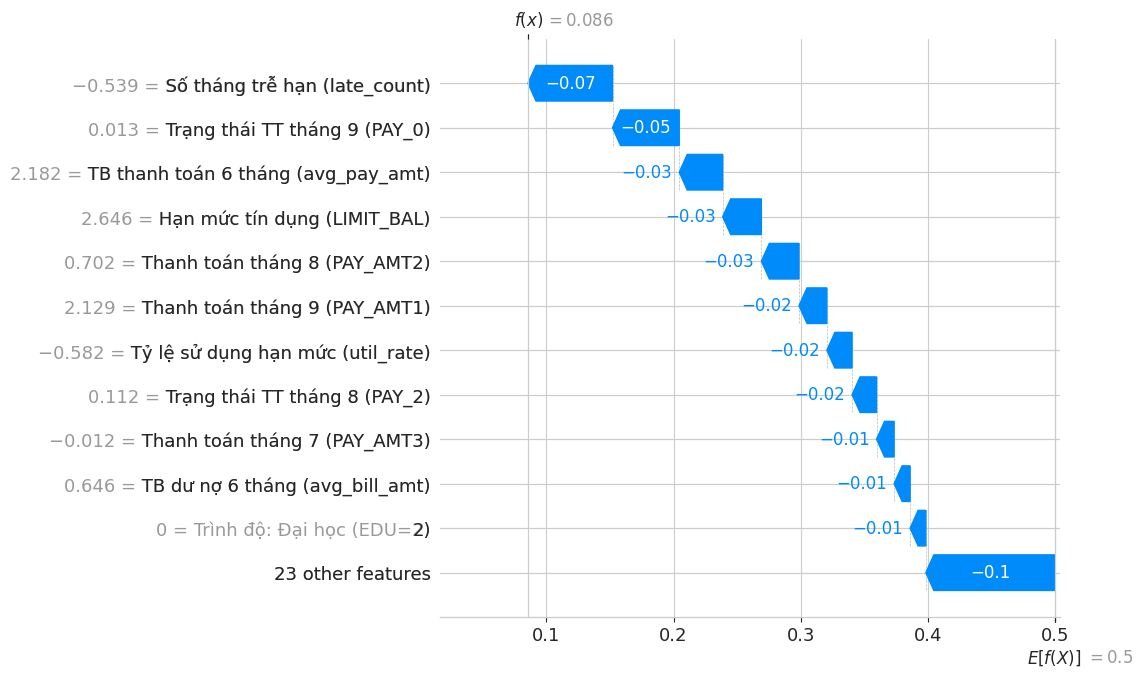


────────────────────────────────────────────────────────────
  High Risk — hồ sơ rủi ro cao nhất
  PD dự báo = 0.9392 | Thực tế vỡ nợ = 1


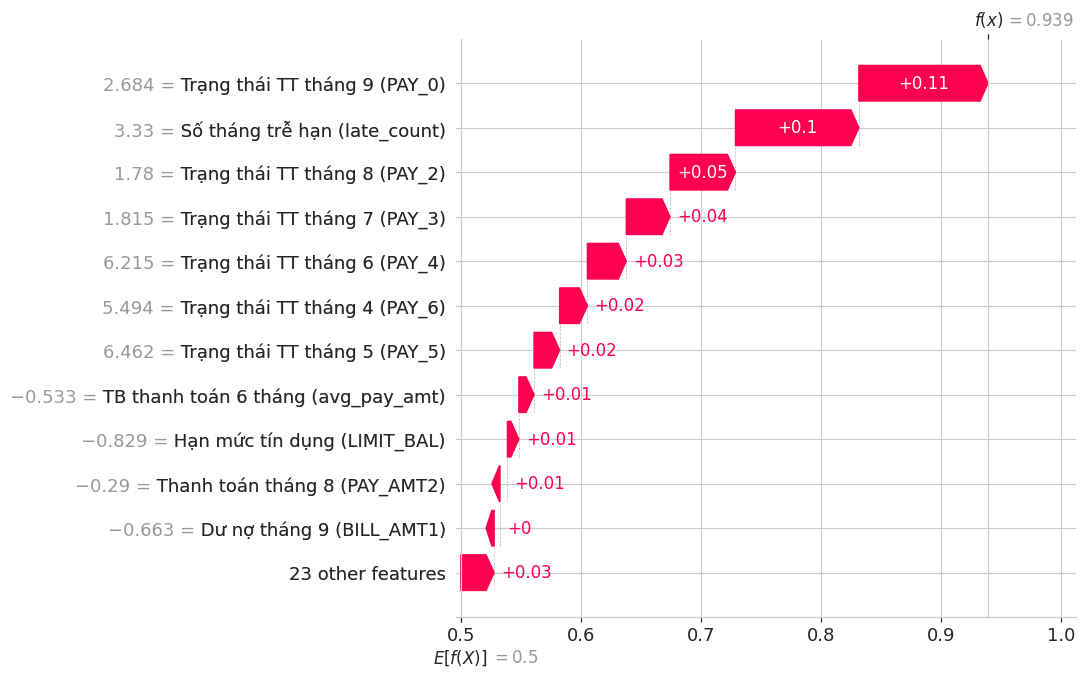


────────────────────────────────────────────────────────────
  Medium Risk — biên giới high_risk (edge-case)
  PD dự báo = 0.3200 | Thực tế vỡ nợ = 0


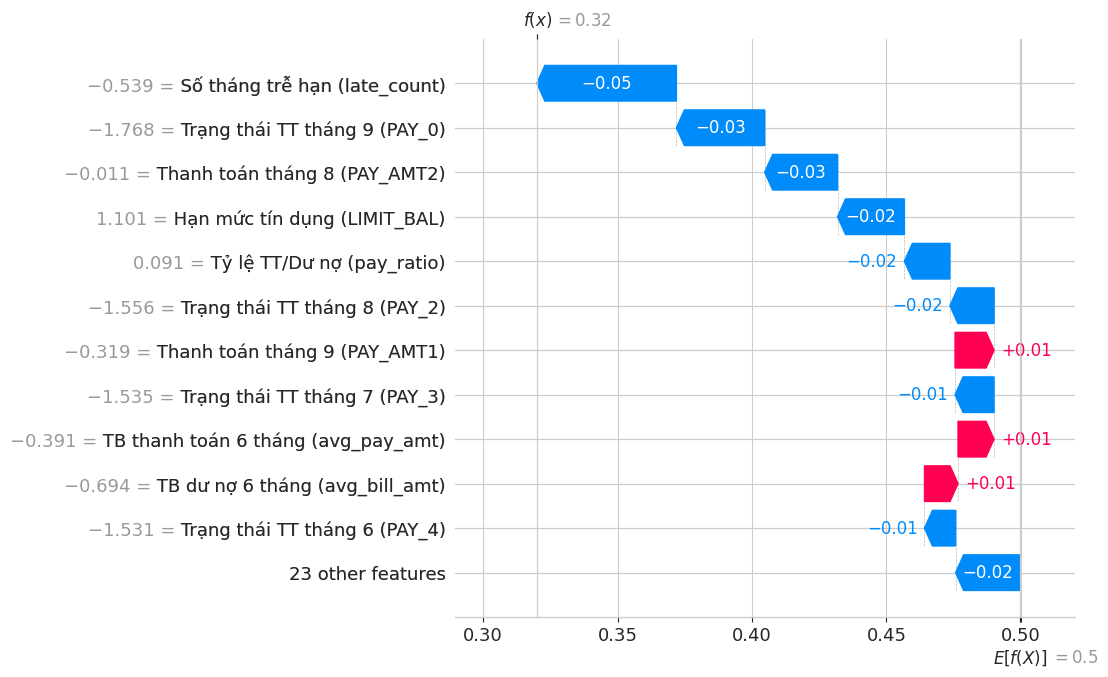

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 18 — WATERFALL PLOTS: 3 HỒ SƠ ĐẠI DIỆN
# Low Risk / High Risk / Edge-case Medium Risk
# ══════════════════════════════════════════════════════════════════════════════
base_ev = decision_explainer.expected_value
if isinstance(base_ev, (list, np.ndarray)):
    base_ev = float(np.atleast_1d(base_ev)[1]
                    if len(np.atleast_1d(base_ev)) > 1
                    else np.atleast_1d(base_ev)[0])
else:
    base_ev = float(base_ev)

# Chọn 3 hồ sơ điển hình:
#   1. Low Risk:    PD nhỏ nhất trong nhóm Low
#   2. High Risk:   PD lớn nhất trong nhóm High
#   3. Edge-case:   khách hàng Medium Risk gần nhất với high_risk_threshold
def get_case_idx(risk_level, selector_fn):
    subset = rq3_test_df[rq3_test_df["Risk Level"].astype(str) == risk_level]
    if len(subset) == 0:
        return None
    return selector_fn(subset["PD"])

cases = [
    ("Low Risk — hồ sơ rủi ro thấp nhất",
     get_case_idx("Low Risk",    lambda s: s.idxmin())),
    ("High Risk — hồ sơ rủi ro cao nhất",
     get_case_idx("High Risk",   lambda s: s.idxmax())),
    ("Medium Risk — biên giới high_risk (edge-case)",
     get_case_idx("Medium Risk",
                  lambda s: (s - high_risk_threshold).abs().idxmin())),
]

for case_label, case_idx in cases:
    if case_idx is None:
        print(f"[SKIP] {case_label}: không có hồ sơ trong nhóm.")
        continue

    row_pos = rq3_test_df.index.get_loc(case_idx)
    pd_val  = rq3_test_df.loc[case_idx, "PD"]
    true_y  = int(rq3_test_df.loc[case_idx, "y_true"])

    print(f"\n{'─'*60}")
    print(f"  {case_label}")
    print(f"  PD dự báo = {pd_val:.4f} | Thực tế vỡ nợ = {true_y}")

    exp = shap.Explanation(
        values        = decision_shap_matrix[row_pos],
        base_values   = base_ev,
        data          = X_test_t_full_df.iloc[row_pos].values,
        feature_names = display_feature_names,  # [FIX-7] tên thân thiện
    )
    shap.plots.waterfall(exp, max_display=12, show=True)

In [37]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 19 — BẢNG TỔNG HỢP RQ3
# ══════════════════════════════════════════════════════════════════════════════
rq3_output = risk_summary.merge(
    decision_table.rename(columns={"Nhóm rủi ro": "Risk Level"})
    [["Risk Level", "Khuyến nghị", "Căn cứ"]],
    on="Risk Level", how="left",
)
display(rq3_output)

print("\nKết luận RQ3:")
print(
    "Mô hình tạo ra điểm rủi ro/xác suất dự báo (PD) và được minh họa trong "
    "framework hỗ trợ quyết định tín dụng 3 tầng. Ngưỡng phân nhóm được xác định từ "
    "cost matrix (Cost_FN/Cost_FP) và ngưỡng F2-optimized trên OOF train, "
    "có căn cứ kinh tế rõ ràng trong phạm vi giả định nghiên cứu. SHAP tại cấp nhóm "
    "và cấp cá nhân cung cấp khả năng giải thích cách mô hình hình thành dự báo, "
    "qua đó hỗ trợ cán bộ tín dụng kiểm tra và giải trình quyết định. Kết quả này "
    "mang tính hỗ trợ quyết định, không thay thế thẩm định tín dụng thực tế."
)


,Risk Level,n_customers,avg_PD,median_PD,observed_default_rate,Khuyến nghị,Căn cứ
0,Low Risk,380,0.140606,0.144180,0.042105,Phê duyệt,PD dưới ngưỡng cost-optimal (1/(1+5)=0.167): e...
1,Medium Risk,2122,0.248273,0.250166,0.093779,Xem xét thủ công / Yêu cầu bổ sung hồ sơ,PD nằm trong vùng không chắc chắn giữa hai ngư...
2,High Risk,3498,0.539498,0.482508,0.317896,Từ chối / Chuyển lên Hội đồng tín dụng,PD vượt ngưỡng F2-optimized (0.320) được tối ư...



Kết luận RQ3:
Mô hình tạo ra điểm rủi ro/xác suất dự báo (PD) và được minh họa trong framework hỗ trợ quyết định tín dụng 3 tầng. Ngưỡng phân nhóm được xác định từ cost matrix (Cost_FN/Cost_FP) và ngưỡng F2-optimized trên OOF train, có căn cứ kinh tế rõ ràng trong phạm vi giả định nghiên cứu. SHAP tại cấp nhóm và cấp cá nhân cung cấp khả năng giải thích cách mô hình hình thành dự báo, qua đó hỗ trợ cán bộ tín dụng kiểm tra và giải trình quyết định. Kết quả này mang tính hỗ trợ quyết định, không thay thế thẩm định tín dụng thực tế.


In [38]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 20 — [FIX-7] THẢO LUẬN GIỚI HẠN TRIỂN KHAI
# Đây là phần phân biệt "kết quả nghiên cứu" với "demo kỹ thuật".
# Bắt buộc có trong phần kết luận của khóa luận để RQ3 đạt mức học thuật.
# ══════════════════════════════════════════════════════════════════════════════
limitations_text = """
╔══════════════════════════════════════════════════════════════════════════════╗
║  GIỚI HẠN VÀ ĐIỀU KIỆN TRIỂN KHAI TRONG THỰC TẾ (Bắt buộc thảo luận)     ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. MODEL DRIFT & TÁI HUẤN LUYỆN
   Mô hình được huấn luyện trên dữ liệu tại Đài Loan, tháng 10/2005. Hành vi tín dụng
   thay đổi theo chu kỳ kinh tế, chính sách lãi suất, và nhân khẩu học.
   Để triển khai thực tế: cần giám sát PSI (Population Stability Index) hàng
   tháng và tái huấn luyện khi PSI > 0.2 (thực tiễn Basel II/III).

2. FAIRNESS & ĐẶC TRƯNG BẢO VỆ (Protected Attributes)
   Biến SEX và MARRIAGE có trong mô hình. Ở nhiều quốc gia (EU AI Act, ECOA
   của Mỹ, và nguyên tắc tín dụng công bằng của NHNN Việt Nam), việc dùng
   giới tính hoặc tình trạng hôn nhân trực tiếp trong quyết định tín dụng
   bị hạn chế. Cần kiểm tra Equalized Odds và Demographic Parity trước
   khi triển khai.

3. CALIBRATION (ĐỘ TIN CẬY CỦA XÁC SUẤT)
   PD trong notebook được dùng như điểm rủi ro tương đối để xếp hạng và
   phân nhóm khách hàng. Tuy nhiên, XGBoost và Random Forest không tự động
   tạo xác suất được calibrate tốt. Nếu triển khai thực tế, cần dùng
   Platt Scaling hoặc Isotonic Regression trên validation set riêng để
   đảm bảo PD=0.3 có ý nghĩa gần với tỷ lệ vỡ nợ quan sát 30%.

4. GIẢI THÍCH ĐƯỢC vs. GIẢI THÍCH HỢP LÝ
   SHAP cung cấp explainability kỹ thuật, nhưng không đảm bảo interpretability
   cho người không có nền tảng ML. Cán bộ tín dụng cần được đào tạo để
   đọc waterfall plot và hiểu hướng tác động. Tên feature đã được làm thân
   thiện trong notebook này nhưng vẫn cần kiểm tra với domain expert.

5. PHẠM VI ÁP DỤNG
   Notebook này sử dụng bộ dữ liệu UCI Taiwan Credit Card (tháng 10/2005).
   Kết quả KHÔNG thể tự động áp dụng cho thị trường Việt Nam mà không có
   validation trên dữ liệu cục bộ và điều chỉnh ngưỡng theo risk appetite
   của từng tổ chức tín dụng.
"""
print(limitations_text)


╔══════════════════════════════════════════════════════════════════════════════╗
║  GIỚI HẠN VÀ ĐIỀU KIỆN TRIỂN KHAI TRONG THỰC TẾ (Bắt buộc thảo luận)     ║
╚══════════════════════════════════════════════════════════════════════════════╝

1. MODEL DRIFT & TÁI HUẤN LUYỆN
   Mô hình được huấn luyện trên dữ liệu tại Đài Loan, tháng 10/2005. Hành vi tín dụng
   thay đổi theo chu kỳ kinh tế, chính sách lãi suất, và nhân khẩu học.
   Để triển khai thực tế: cần giám sát PSI (Population Stability Index) hàng
   tháng và tái huấn luyện khi PSI > 0.2 (thực tiễn Basel II/III).

2. FAIRNESS & ĐẶC TRƯNG BẢO VỆ (Protected Attributes)
   Biến SEX và MARRIAGE có trong mô hình. Ở nhiều quốc gia (EU AI Act, ECOA
   của Mỹ, và nguyên tắc tín dụng công bằng của NHNN Việt Nam), việc dùng
   giới tính hoặc tình trạng hôn nhân trực tiếp trong quyết định tín dụng
   bị hạn chế. Cần kiểm tra Equalized Odds và Demographic Parity trước
   khi triển khai.

3. CALIBRATION (ĐỘ TIN CẬY CỦA XÁC SUẤT)
   PD trong no

---
## Ghi chú phương pháp (combined v7 — bản chạy được)

Notebook này lấy `KLTN(2).ipynb` làm nền ổn định và bổ sung các phần tốt từ v6 nhưng loại bỏ các yếu tố dễ gây phản biện.

**Các điểm đã kết hợp/sửa:**

| Nhóm sửa | Nội dung |
|---|---|
| Reproducibility | Cell đọc dữ liệu tự tìm file CSV ở Colab/local/Jupyter; chỉ cần đặt file dữ liệu cùng thư mục hoặc sửa `DATA_PATH`. |
| Feature Engineering | Bổ sung công thức toán cho `avg_bill_amt`, `util_rate`, `avg_pay_amt`, `pay_ratio`, `late_count`. |
| Imbalance | Bổ sung bảng tỷ lệ default và imbalance ratio trước khi dùng SMOTE. |
| SMOTE/F2 | Bổ sung công thức SMOTE, Fβ/F2-score và cost-optimal threshold. |
| Pipeline | Giữ SMOTE trong `ImbPipeline`, tránh leakage; không thêm `class_weight`/`scale_pos_weight` để tránh xử lý mất cân bằng hai lần. |
| Model fairness | Giữ search space tương đối công bằng giữa LR/RF/XGBoost; không dùng comment kiểu “ưu tiên ensemble”. |
| Evaluation | Giữ Bootstrap CI, KS Statistic và thay Bootstrap Paired AUC Test bằng Bootstrap 95% CI cho Delta AUC để tránh p-value sai. |
| Calibration | Bổ sung Brier Score + Reliability Diagram; diễn giải PD như điểm rủi ro tương đối nếu chưa calibration production. |
| RQ3 | Bổ sung Wilson 95% CI cho default rate theo nhóm rủi ro và sensitivity analysis cho FN:FP = 3:1, 5:1, 7:1, 10:1. |
| SHAP | Giữ tên biến thân thiện và sửa diễn giải theo hướng “đóng góp vào dự báo”, không khẳng định quan hệ nhân quả. |
| External validity | Sửa phạm vi dữ liệu thành Đài Loan, tháng 10/2005; nhấn mạnh không suy rộng trực tiếp sang Việt Nam. |

**Lưu ý khi nộp:** chạy `Run All` từ đầu đến cuối để tạo output mới, tránh dùng output cũ từ các notebook trước.
